In [1]:
################################################################################
# CELL 1: Load Data and Perform Global Clustering (Run this cell only once)
################################################################################

#!/usr/bin/env python3
"""
CELL 1: Data Loading and Global Processing

This cell loads the unified CSV data file into a pandas DataFrame and performs
global K-Means clustering on the entire dataset. It should be run once to make
the processed data available for the visualization cell that follows.
"""

import pandas as pd
from pathlib import Path
import logging
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
import numpy as np

# ------------------------------------------------------------------- #
# Configuration - EDIT THIS VALUE
# ------------------------------------------------------------------- #
# Path to the unified data CSV file.
CSV_PATH = '/home/jtb3sud/PARCtorch/PARCtorch/scripts/eval_results/hmx/per_pixel_analysis_job_2637997/ALL_SAMPLES_upBlock_3_unified_data.csv'

# --- Setup ---
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

# --- Load and Process Data from CSV ---
display(Markdown(f"### Loading data from `{CSV_PATH}`..."))
try:
    df = pd.read_csv(CSV_PATH)
    display(Markdown(f"**Successfully loaded data with {len(df)} rows.**"))
    
    # --- Perform global K-Means clustering on the ENTIRE dataframe ---
    if 'strain_rate_magnitude' in df.columns:
        logging.info("Performing global K-Means clustering on the entire CSV's strain data...")
        strain_values = df[['strain_rate_magnitude']].values
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(strain_values)
        centers = kmeans.cluster_centers_.flatten()
        label_map = {np.argmin(centers): "low", np.argmax(centers): "high"}
        df['strain_category'] = kmeans.predict(strain_values)
        df['strain_category'] = df['strain_category'].map(label_map)
        logging.info("Global clustering complete. 'strain_category' column added.")
    
    display(df.head())
    
    available_samples = sorted(df['sample_id'].unique())
    display(Markdown(f"**Available `sample_id` values:** `{available_samples}`"))
    
except FileNotFoundError:
    logging.error(f"Error: CSV file not found at {CSV_PATH}")
    df = None

### Loading data from `/home/jtb3sud/PARCtorch/PARCtorch/scripts/eval_results/hmx/per_pixel_analysis_job_2637997/ALL_SAMPLES_upBlock_3_unified_data.csv`...

**Successfully loaded data with 15138816 rows.**

2026-01-27 10:31:40,370 [INFO] Performing global K-Means clustering on the entire CSV's strain data...
2026-01-27 10:32:13,091 [INFO] Global clustering complete. 'strain_category' column added.


,anisotropy,orientation,ellipse_area,shear_magnitude,deformation_magnitude,centroid_skew_magnitude,sample_id,timestep,pixel_y,pixel_x,...,offset_k4_dx,offset_k5_dy,offset_k5_dx,offset_k6_dy,offset_k6_dx,offset_k7_dy,offset_k7_dx,offset_k8_dy,offset_k8_dx,strain_category
0,1.72837,99.8258,0.544126,0.044890,0.897663,0.657450,0,0,0,0,...,-0.192011,0.214912,-0.116833,-0.054899,1.166870,-0.394373,0.264102,-0.082831,-0.127238,low
1,11.15100,99.3157,0.409407,0.133446,1.168640,0.522894,0,0,0,1,...,-1.044490,0.454250,-0.737772,-0.174426,0.739307,-0.376365,0.289990,-0.234415,-0.870750,low
2,14.27360,98.0131,0.498646,0.119964,1.256860,0.415934,0,0,0,2,...,-1.491630,0.348096,-0.949297,-0.208395,0.692051,-0.404975,0.334967,-0.336500,-1.137830,low
3,14.61610,98.8145,0.505113,0.132033,1.264040,0.404223,0,0,0,3,...,-1.518630,0.347181,-0.984191,-0.224456,0.700159,-0.427169,0.329689,-0.309857,-1.165180,low
4,16.40910,99.1750,0.482734,0.139326,1.275230,0.426769,0,0,0,4,...,-1.490070,0.381424,-0.977012,-0.226798,0.714672,-0.442819,0.330513,-0.288868,-1.149740,low


**Available `sample_id` values:** `[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]`

/tmp/ipykernel_658061/3689073276.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_658061/3689073276.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure 1 (A-D) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/hmx_scripts/em_combined_vis_from_notebook/fig1_abcd_3_sample12_strain_rate_magnitude.pdf`

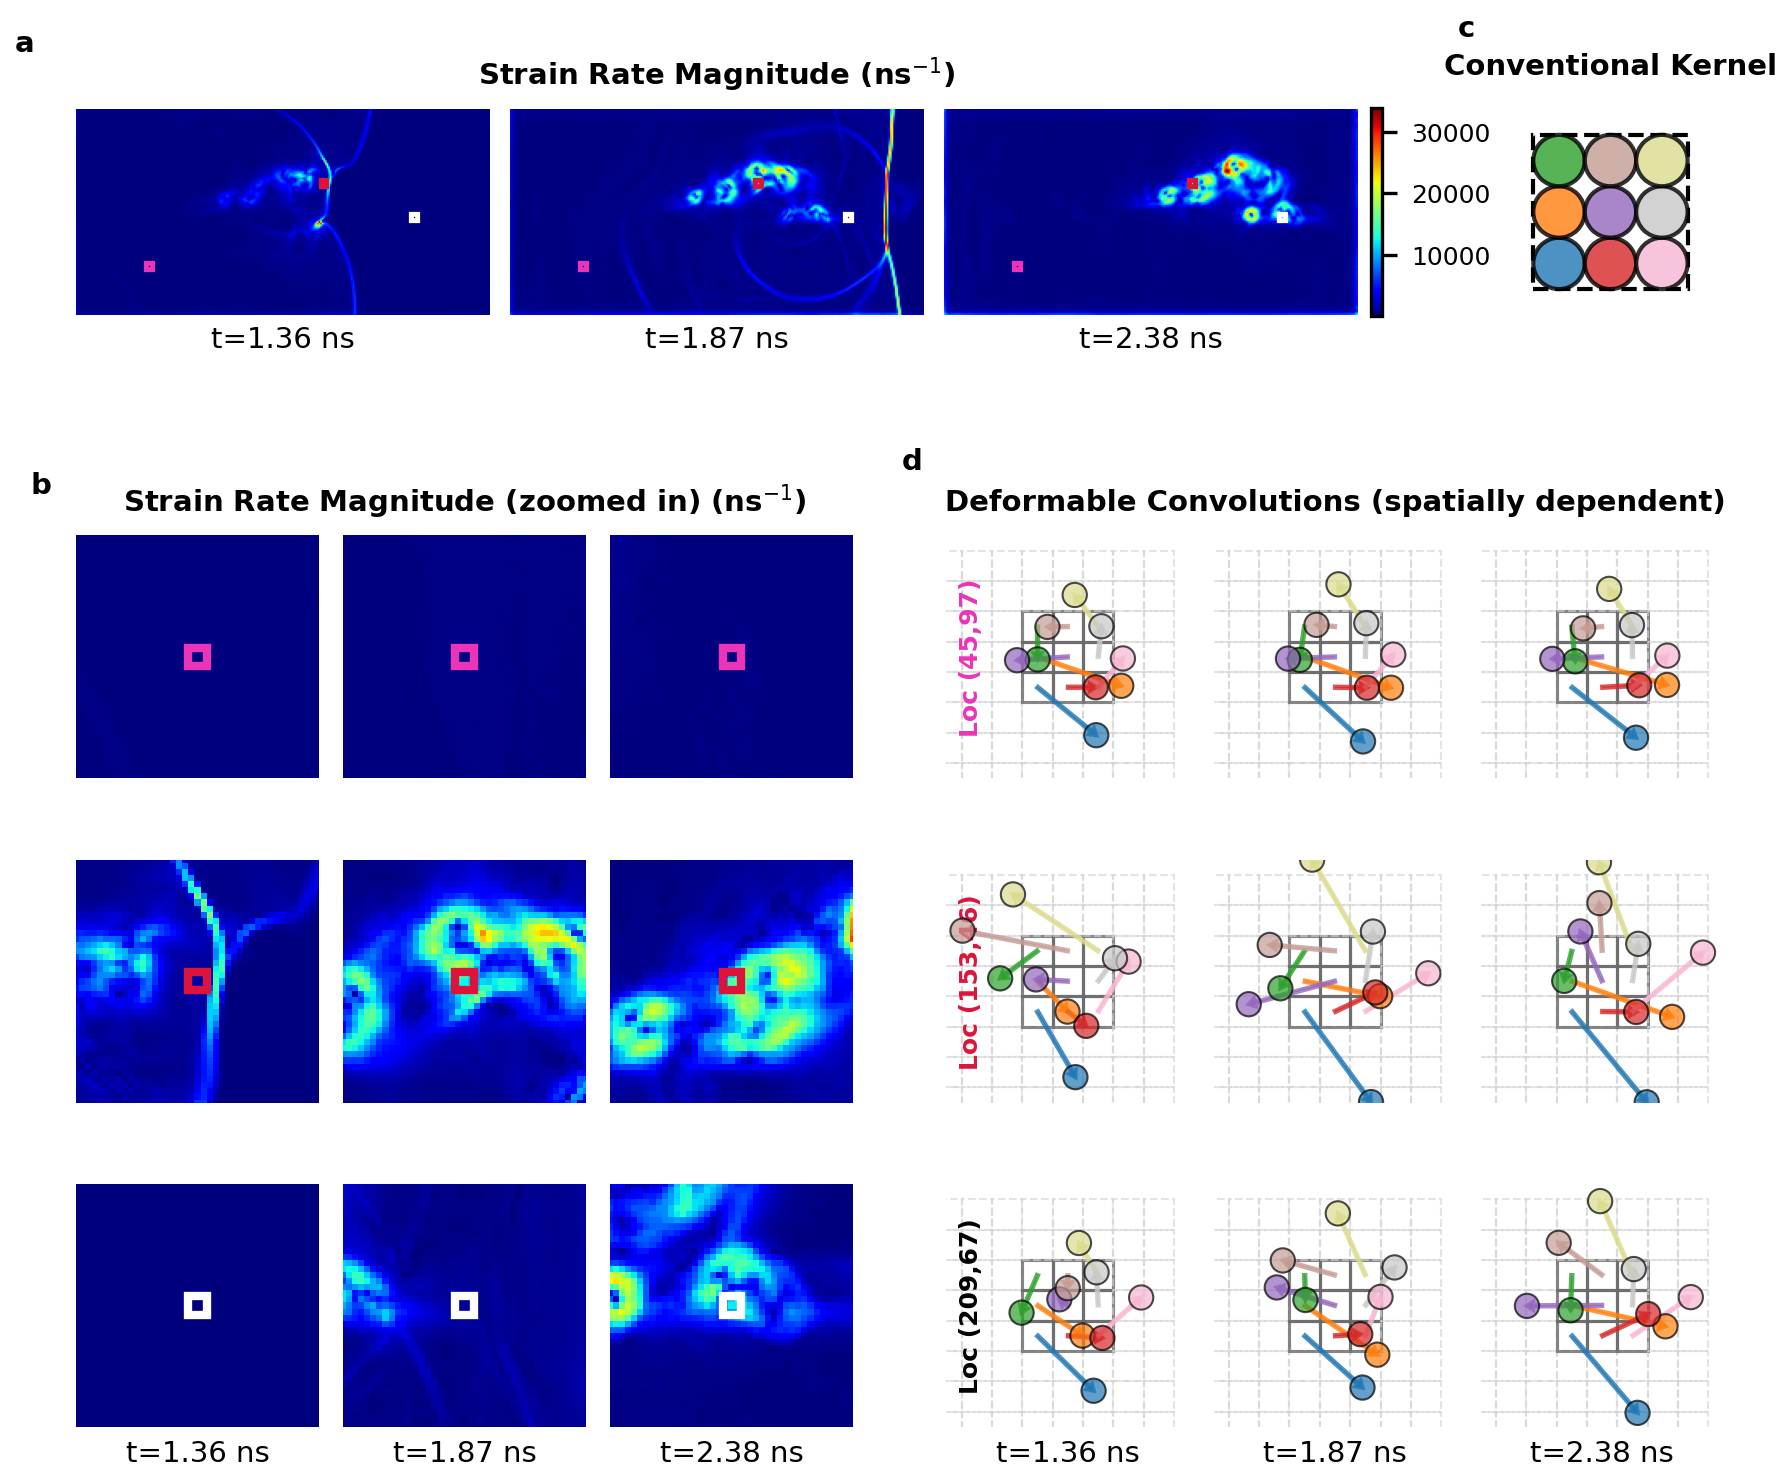

In [2]:
#!/usr/bin/env python3
"""
Figure 1: Panels A, B, C, D - Spatial Visualization
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Circle
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "em_combined_vis_from_notebook"
VISUALIZATION_METRIC = 'strain_rate_magnitude'
SPATIAL_LOCATIONS = [45, 97, 153, 46, 209, 67]
TIMESTEPS = [7, 10, 13]  # keep actual timesteps for data extraction
SAMPLE_ID = 12

# Mapping for display labels only
TIMESTEP_LABELS = {
    7: "1.36 ns",
    10: "1.87 ns",
    13: "2.38 ns"
}

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell first.")
if 'CSV_PATH' not in globals():
    raise NameError("Variable 'CSV_PATH' not found. Please define it with the path to your data file.")

# Static variables
color_map = plt.get_cmap("tab20")
kernel_colors = [color_map(i) for i in np.linspace(0, 1, 9, endpoint=False)]
grid_coords = np.array([[-1,-1],[-1,0],[-1,1],[0,-1],[0,0],[0,1],[1,-1],[1,0],[1,1]], dtype=np.float32)
zoom_limits = {"initial_doubleConv": 3, "upBlock_3": 3}

def set_publication_style():
    plt.rcParams.update({
        #'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_abcd_figure(spatial_locations, display_channels_by_ts, offset_fields_by_ts,
                         layer_key, output_path, title_prefix):
    set_publication_style()
    num_locations = len(spatial_locations)
    timesteps_to_plot = sorted(display_channels_by_ts.keys())
    num_ts = len(timesteps_to_plot)

    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * (0.28 * num_locations + 0.5)
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    
    gs_main = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, num_locations * 0.35], hspace=-0.46)
    a_c_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0],
                                              width_ratios=[num_ts, 0.5], wspace=0.08)
    a_gs = gridspec.GridSpecFromSubplotSpec(1, num_ts, subplot_spec=a_c_gs[0, 0], wspace=0.05)
    b_d_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1],
                                              width_ratios=[1, 1], wspace=0.12)
    
    b_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 0],
                                            wspace=0.1, hspace=-0.6)
    d_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 1],
                                            wspace=0.1, hspace=-0.6)

    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    cmap = "jet"

    # Changed: white square instead of black
    rec_colors = ['#eb34b7', 'crimson', '#FFFFFF', '#34eb3d']

    H_offset, W_offset = next(iter(display_channels_by_ts.values())).shape

    # Panel A - Single title above all three timesteps
    panel_a_ims = []  # Store image objects
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        ax_full_view = fig.add_subplot(a_gs[0, i])
        im = ax_full_view.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        panel_a_ims.append(im)
        
        # Display label from TIMESTEP_LABELS mapping
        ts_label = TIMESTEP_LABELS.get(ts, str(ts))
        
        # Only show title on the middle subplot (i == 1)
        if i == 1:
            ax_full_view.set_title(f"{title_prefix} (ns$^{{-1}}$)", fontsize=7, weight='bold')
        
        # Add time label at bottom
        ax_full_view.text(0.5, -0.05, f"t={ts_label}", transform=ax_full_view.transAxes,
                         ha='center', va='top', fontsize=7)
    
        ax_full_view.axis('off')
        if i == 0:
            ax_full_view.text(-0.1, 1.25, 'a', transform=ax_full_view.transAxes, **label_props)
        
        for loc_idx, (cur_x, cur_y) in enumerate(spatial_locations):
            ax_full_view.add_patch(Rectangle((cur_x - 1.5, cur_y - 1.5), 3, 3, lw=1.5,
                                             ec=rec_colors[loc_idx % len(rec_colors)], fc='none'))
    
    # Add colorbar without label
    cbar = fig.colorbar(panel_a_ims[-1], ax=fig.axes[:num_ts], fraction=0.046, pad=0.01, shrink=0.15)
    cbar.ax.tick_params(labelsize=6)
    
    # Panel B - Single title with "zoomed in"
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        ts_label = TIMESTEP_LABELS.get(ts, str(ts))
        for zoom_idx, (zoom_loc_x, zoom_loc_y) in enumerate(spatial_locations):
            ax_zoom = fig.add_subplot(b_gs[zoom_idx, i])
            if zoom_idx == 0 and i == 1:
                # Show title with "zoomed in" only on middle subplot of top row
                ax_zoom.set_title(f"{title_prefix} (zoomed in) (ns$^{{-1}}$)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if zoom_idx == num_locations - 1:
                ax_zoom.text(0.5, -0.05, f"t={ts_label}", transform=ax_zoom.transAxes,
                           ha='center', va='top', fontsize=7)
            
            ax_zoom.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
            ax_zoom.set_xlim(zoom_loc_x - 20, zoom_loc_x + 20)
            ax_zoom.set_ylim(zoom_loc_y + 20, zoom_loc_y - 20)
            ax_zoom.set_aspect('equal', adjustable='box')
            ax_zoom.add_patch(Rectangle((zoom_loc_x - 1.5, zoom_loc_y - 1.5), 3, 3, lw=2,
                                        ec=rec_colors[zoom_idx % len(rec_colors)], fc='none'))
            ax_zoom.axis('off')
            if i == 0 and zoom_idx == 0:
                ax_zoom.text(-0.1, 1.15, 'b', transform=ax_zoom.transAxes, **label_props)

    # Panel C
    ax_conv_kernel = fig.add_subplot(a_c_gs[0, 1])
    ax_conv_kernel.set_title("Conventional Kernel", fontsize=7, weight='bold')
    ax_conv_kernel.set_aspect('equal', adjustable='box')
    ax_conv_kernel.set_xlim(-2.2, 2.2)
    ax_conv_kernel.set_ylim(-2.2, 2.2)
    ax_conv_kernel.axis("off")
    ax_conv_kernel.text(-0.1, 1.25, 'c', transform=ax_conv_kernel.transAxes, **label_props)
    ax_conv_kernel.add_patch(Rectangle((-1.5, -1.5), 3, 3, lw=1, ec='k', fc='none', linestyle='--'))
    for i_el in range(9):
        ax_conv_kernel.add_patch(Circle((grid_coords[i_el][0], grid_coords[i_el][1]),
                                        radius=0.5, lw=1, ec='k', fc=kernel_colors[i_el], alpha=0.8))

    # Panel D - Single title with "spatially dependent"
    for i_loc, (cur_x, cur_y) in enumerate(spatial_locations):
        for j_ts, ts in enumerate(timesteps_to_plot):
            ts_label = TIMESTEP_LABELS.get(ts, str(ts))
            ax_def = fig.add_subplot(d_gs[i_loc, j_ts])
            if i_loc == 0 and j_ts == 1:
                # Show "Deformable Convolutions (spatially dependent)" title on middle subplot only
                ax_def.set_title("Deformable Convolutions (spatially dependent)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if i_loc == num_locations - 1:
                ax_def.text(0.5, -0.05, f"t={ts_label}", transform=ax_def.transAxes,
                          ha='center', va='top', fontsize=7)
            
            if i_loc == 0 and j_ts == 0:
                ax_def.text(-0.1, 1.25, 'd', transform=ax_def.transAxes, **label_props)
            zoom_lim = zoom_limits.get(layer_key, 4)
            if j_ts == 0:
                # Determine text color: black for white square (index 2), keep original color for others
                text_color = 'black' if i_loc == 2 else rec_colors[i_loc % len(rec_colors)]
                ax_def.text(-zoom_lim * 0.8, 0, f"Loc ({cur_x},{cur_y})", rotation=90, size=6,
                            ha='center', va='center',
                            color=text_color, fontweight='bold')
            ax_def.set_aspect('equal', adjustable='box')
            ax_def.set_xlim(-zoom_lim, zoom_lim)
            ax_def.set_ylim(-zoom_lim, zoom_lim)
            ax_def.axis("off")
            grid_range = int(np.ceil(zoom_lim))
            for x_g in range(-grid_range, grid_range):
                for y_g in range(-grid_range, grid_range):
                    is_central = -1 <= x_g < 2 and -1 <= y_g < 2
                    ax_def.add_patch(Rectangle((x_g - 0.5, y_g - 0.5), 1, 1,
                                               lw=0.75 if is_central else 0.5,
                                               ec='dimgray' if is_central else 'lightgray',
                                               fc='none', ls='-' if is_central else '--',
                                               alpha=0.8 if is_central else 0.6))
            offsets_at_loc = offset_fields_by_ts.get(ts, {}).get((cur_y, cur_x), np.zeros((9, 2)))
            for i_el in range(9):
                offset_yx = offsets_at_loc[i_el]
                offset_vec = np.array([offset_yx[1], -offset_yx[0]])  # Negate y for correct direction
                start_point = grid_coords[i_el]
                endpoint = start_point + offset_vec
                
                if np.linalg.norm(offset_vec) > 0.01: 
                    ax_def.arrow(start_point[0], start_point[1],
                                 offset_vec[0], offset_vec[1],
                                 head_width=0.25, head_length=0.2,
                                 width=0.04, fc=kernel_colors[i_el],
                                 ec=kernel_colors[i_el], alpha=0.8,
                                 length_includes_head=True)
                
                ax_def.add_patch(Circle((endpoint[0], endpoint[1]), radius=0.4,
                                        lw=0.5, ec='k', fc=kernel_colors[i_el], alpha=0.7, zorder=10))

    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
spatial_locs = list(zip(SPATIAL_LOCATIONS[::2], SPATIAL_LOCATIONS[1::2]))

sample_df = df[df['sample_id'] == SAMPLE_ID].copy()
if sample_df.empty:
    logging.error(f"No data found for sample_id {SAMPLE_ID}.")
else:
    offsets_by_ts, preds_by_ts = {}, {}
    for ts in TIMESTEPS:
        ts_df = sample_df[sample_df['timestep'] == ts]
        if ts_df.empty: continue
        preds_by_ts[ts] = ts_df.pivot_table(index='pixel_y', columns='pixel_x', values=VISUALIZATION_METRIC).values
        offset_cols = [f'offset_k{i}_d{ax}' for i in range(9) for ax in ['y', 'x']]
        loc_df = ts_df.set_index(['pixel_y', 'pixel_x'])
        offsets_by_ts[ts] = {}
        for x, y in spatial_locs:
            if (y, x) in loc_df.index:
                offsets_flat = loc_df.loc[(y, x), offset_cols].values
                offsets_by_ts[ts][(y, x)] = np.stack([offsets_flat[::2], offsets_flat[1::2]], axis=-1)

    if preds_by_ts:
        layer_name = Path(CSV_PATH).stem.split('_unified_data')[0].split('_')[-1]
        clean_metric_name = VISUALIZATION_METRIC.replace(" ", "_").replace("(", "").replace(")", "")
        out_file_pdf = Path(OUTPUT_DIR) / f"fig1_abcd_{layer_name}_sample{SAMPLE_ID}_{clean_metric_name}.pdf"
        out_file_png = out_file_pdf.with_suffix('.png')
        
        title_prefix = "Strain Rate Magnitude" if VISUALIZATION_METRIC == 'strain_rate_magnitude' else VISUALIZATION_METRIC.replace("_", " ").title()

        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_pdf, title_prefix)
        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_png, title_prefix)

        display(Markdown(f"### Figure 1 (A-D) saved to: `{out_file_pdf.resolve()}`"))
        display(Image(filename=out_file_png))

2026-01-27 10:52:41,599 [INFO] Found 14 timesteps for Sample 12
2026-01-27 10:52:41,758 [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


Generating GIF... t=0 baseline will be shown as faint grey ghosts.
GIF saved: em_combined_vis_from_notebook/deformable_kernel_stacked_v3_baseline.gif


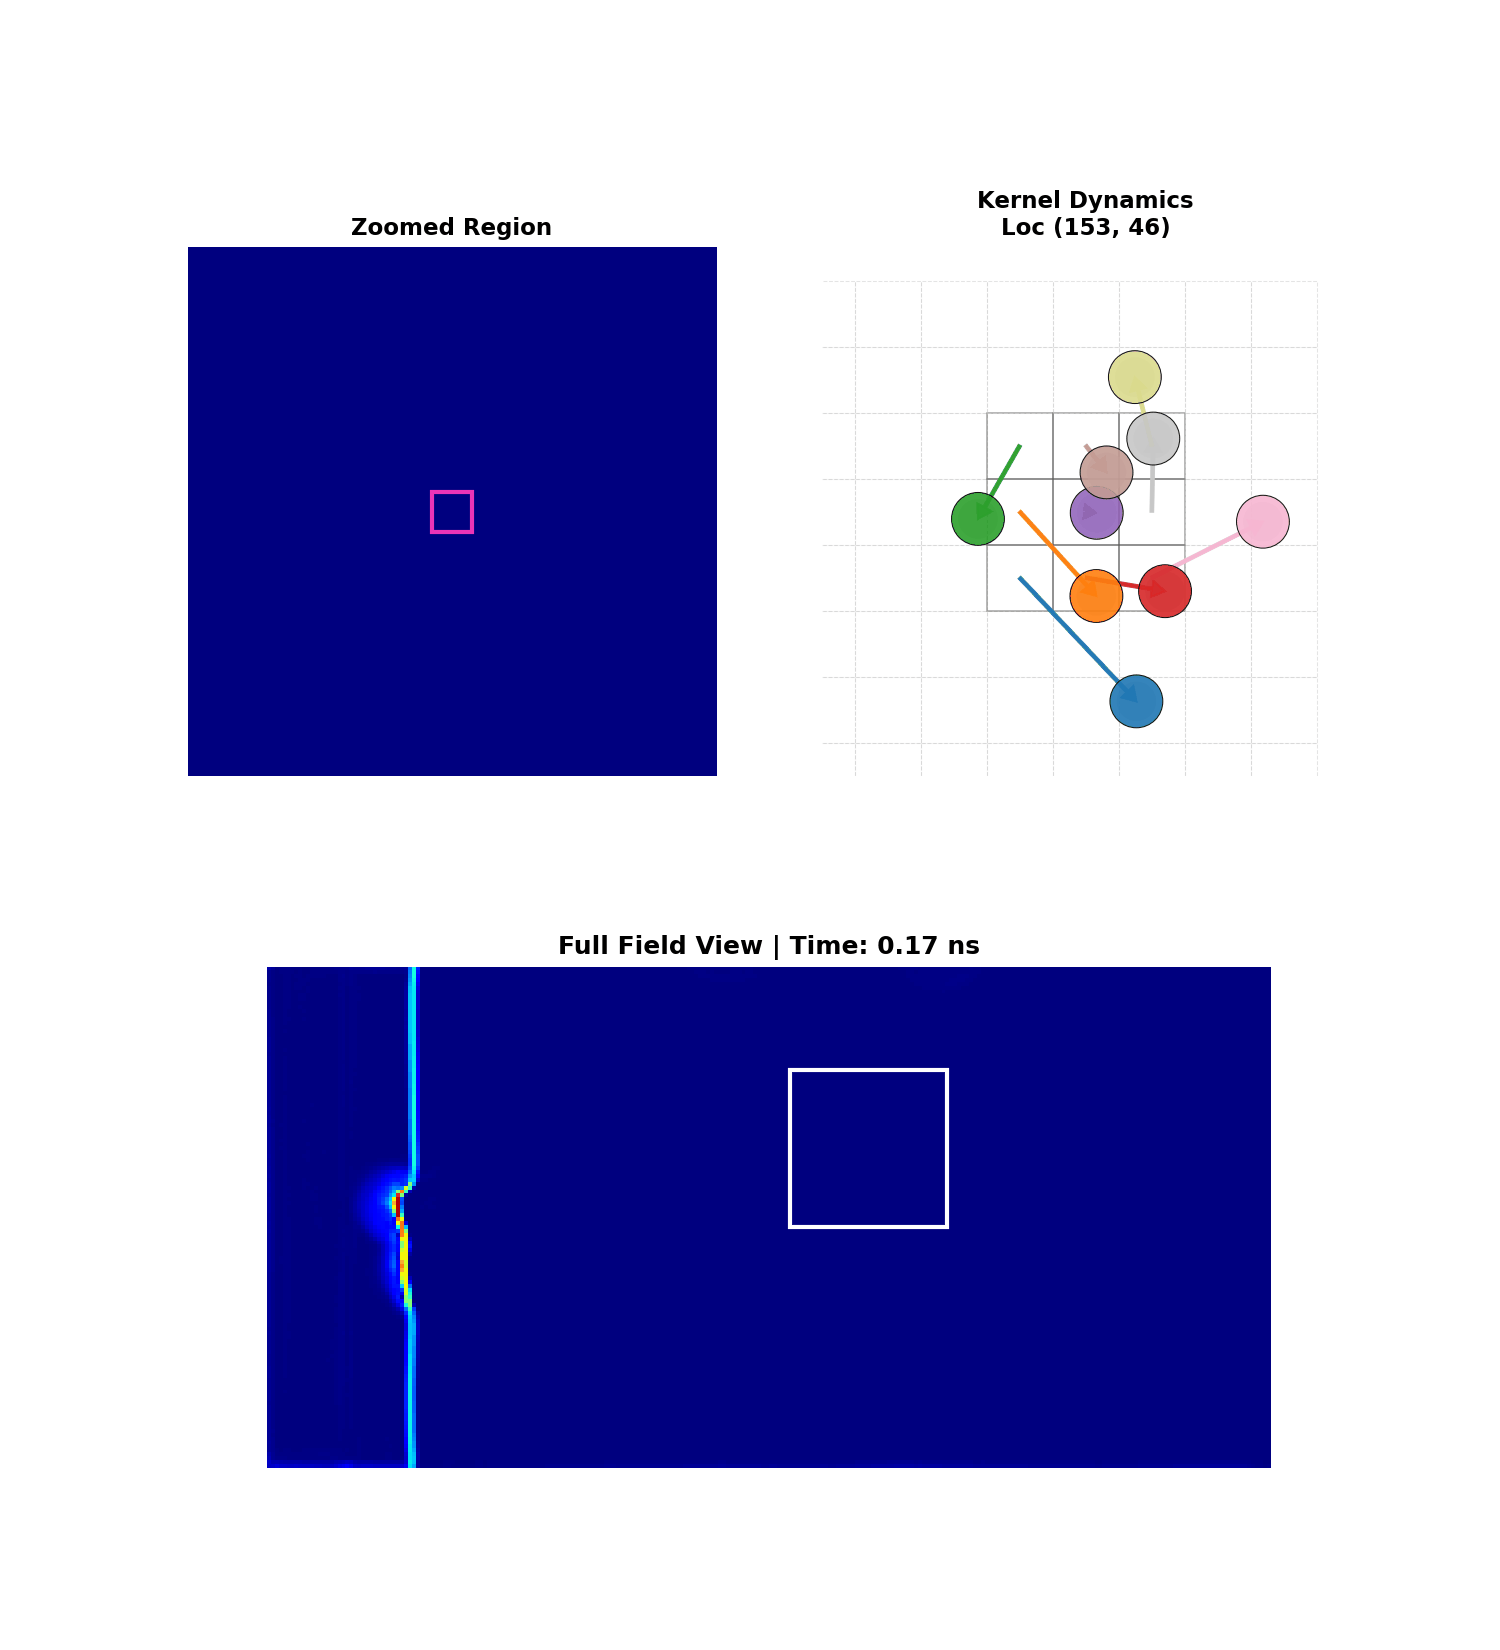

In [12]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
import logging

# ------------------------------------------------------------------- #
# Configuration & Data Extraction (Same as before)
# ------------------------------------------------------------------- #
TARGET_LOC_INDEX = 1   # (153, 46)
GIF_FPS = 2
GIF_OUTPUT_NAME = "deformable_kernel_stacked_v3_baseline.gif"
DT = 0.17

sample_df = df[df['sample_id'] == SAMPLE_ID].copy()
all_timesteps = sorted(sample_df['timestep'].unique())
logging.info(f"Found {len(all_timesteps)} timesteps for Sample {SAMPLE_ID}")

full_preds_by_ts = {}
full_offsets_by_ts = {}

spatial_locs = list(zip(SPATIAL_LOCATIONS[::2], SPATIAL_LOCATIONS[1::2]))
target_x, target_y = spatial_locs[TARGET_LOC_INDEX]
offset_cols = [f'offset_k{i}_d{ax}' for i in range(9) for ax in ['y', 'x']]

for ts in all_timesteps:
    ts_df = sample_df[sample_df['timestep'] == ts]
    if ts_df.empty: continue
    full_preds_by_ts[ts] = ts_df.pivot_table(index='pixel_y', columns='pixel_x', values=VISUALIZATION_METRIC).values
    
    loc_row = ts_df[(ts_df['pixel_y'] == target_y) & (ts_df['pixel_x'] == target_x)]
    if not loc_row.empty:
        offsets_flat = loc_row[offset_cols].values[0]
        full_offsets_by_ts[ts] = np.stack([offsets_flat[::2], offsets_flat[1::2]], axis=-1)
    else:
        full_offsets_by_ts[ts] = np.zeros((9, 2))

# ------------------------------------------------------------------- #
# Animation Function with New Layout and Baseline Visualization
# ------------------------------------------------------------------- #
def generate_stacked_gif_v3(target_loc_idx, display_channels_by_ts, offset_dict, 
                            all_ts_list, layer_key, output_path):
    
    # Setup Figure: Vertical Layout (Top=Details, Bottom=Map)
    fig = plt.figure(figsize=(10, 11), dpi=150)
    # height_ratios=[1, 0.8] gives top row slightly more vertical space
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 0.8], hspace=0.25, wspace=0.2)
    
    # Top Row: Split between Zoom and Kernel
    ax_zoom = fig.add_subplot(gs[0, 0])
    ax_kernel = fig.add_subplot(gs[0, 1])

    # Bottom Row: Spans both columns for Full Field
    ax_full = fig.add_subplot(gs[1, :])
    
    # Configuration
    cmap = "jet"
    zoom_radius = 20
    kernel_zoom_lim = zoom_limits.get(layer_key, 4)
    H_offset, W_offset = next(iter(display_channels_by_ts.values())).shape
    target_x, target_y = spatial_locs[target_loc_idx]
    
    # --- CAPTURE BASELINE OFFSETS (Timestep 0) ---
    initial_ts = all_ts_list[0]
    baseline_offsets = offset_dict.get(initial_ts, np.zeros((9, 2)))

    def update(frame_idx):
        ts = all_ts_list[frame_idx]
        current_time_ns = (ts + 1) * DT
        ts_str = f"{current_time_ns:.2f} ns"
        
        ax_full.clear()
        ax_zoom.clear()
        ax_kernel.clear()
        
        pred_channel = display_channels_by_ts[ts]

        # ==========================================
        # TOP LEFT: Zoomed View (Context)
        # ==========================================
        ax_zoom.imshow(pred_channel, cmap=cmap, origin='upper',
                       extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        ax_zoom.set_xlim(target_x - zoom_radius, target_x + zoom_radius)
        ax_zoom.set_ylim(target_y + zoom_radius, target_y - zoom_radius)
        
        # Indicator Box: The 3x3 kernel center
        rect_kernel_loc = Rectangle((target_x - 1.5, target_y - 1.5), 3, 3, 
                                   lw=2, ec='#eb34b7', fc='none')
        ax_zoom.add_patch(rect_kernel_loc)
        ax_zoom.set_title("Zoomed Region", fontsize=11, weight='bold')
        ax_zoom.axis('off')

        # ==========================================
        # TOP RIGHT: Kernel Dynamics (Micro)
        # ==========================================
        ax_kernel.set_aspect('equal')
        ax_kernel.set_xlim(-kernel_zoom_lim, kernel_zoom_lim)
        ax_kernel.set_ylim(-kernel_zoom_lim, kernel_zoom_lim)
        ax_kernel.axis("off")
        
        # 1. Standard Grid Background (Grey dashed)
        grid_range = int(np.ceil(kernel_zoom_lim))
        for x_g in range(-grid_range, grid_range):
            for y_g in range(-grid_range, grid_range):
                is_central = -1 <= x_g < 2 and -1 <= y_g < 2
                ax_kernel.add_patch(Rectangle((x_g - 0.5, y_g - 0.5), 1, 1,
                                            lw=0.75 if is_central else 0.5,
                                            ec='dimgray' if is_central else 'lightgray',
                                            fc='none', ls='-' if is_central else '--',
                                            alpha=0.6))

        current_offsets = offset_dict.get(ts, np.zeros((9, 2)))
        
        for i_el in range(9):
            start_point = grid_coords[i_el]
            
            # --- 2. Draw BASELINE (Start) Offsets (Faint Ghost Arrows) ---
            base_yx = baseline_offsets[i_el]
            base_vec = np.array([base_yx[1], -base_yx[0]])
            base_endpoint = start_point + base_vec
            
            # Draw baseline dot/arrow in faint grey
            ax_kernel.add_patch(Circle((base_endpoint[0], base_endpoint[1]), radius=0.3,
                                     lw=0, fc='silver', alpha=0.5, zorder=5))
            if np.linalg.norm(base_vec) > 0.01:
                 ax_kernel.arrow(start_point[0], start_point[1], base_vec[0], base_vec[1],
                              head_width=0.2, head_length=0.15, width=0.03, 
                              fc='silver', ec='silver', alpha=0.5, length_includes_head=True, zorder=5)

            # --- 3. Draw CURRENT Offsets (Bright Colored Arrows) ---
            curr_yx = current_offsets[i_el]
            curr_vec = np.array([curr_yx[1], -curr_yx[0]]) 
            curr_endpoint = start_point + curr_vec
            
            if np.linalg.norm(curr_vec) > 0.01: 
                ax_kernel.arrow(start_point[0], start_point[1],
                              curr_vec[0], curr_vec[1],
                              head_width=0.25, head_length=0.2,
                              width=0.04, fc=kernel_colors[i_el],
                              ec=kernel_colors[i_el], alpha=0.9,
                              length_includes_head=True, zorder=10)
            
            ax_kernel.add_patch(Circle((curr_endpoint[0], curr_endpoint[1]), radius=0.4,
                                     lw=0.5, ec='k', fc=kernel_colors[i_el], alpha=0.9, zorder=11))

        ax_kernel.set_title(f"Kernel Dynamics\nLoc ({target_x}, {target_y})", fontsize=11, weight='bold')

        # ==========================================
        # BOTTOM: Full Prediction Field
        # ==========================================
        ax_full.imshow(pred_channel, cmap=cmap, origin='upper',
                       extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        
        # Indicator Box for Zoomed Area
        rect_zoom_area = Rectangle((target_x - zoom_radius, target_y - zoom_radius), 
                                   zoom_radius*2, zoom_radius*2, 
                                   lw=2, ec='white', fc='none', linestyle='-')
        ax_full.add_patch(rect_zoom_area)
        
        ax_full.set_title(f"Full Field View | Time: {ts_str}", fontsize=12, weight='bold')
        ax_full.axis('off')

    # Create Animation
    print(f"Generating GIF... t=0 baseline will be shown as faint grey ghosts.")
    ani = animation.FuncAnimation(fig, update, frames=len(all_ts_list), interval=700)
    
    # Save
    out_file = Path(OUTPUT_DIR) / GIF_OUTPUT_NAME
    ani.save(out_file, writer=PillowWriter(fps=GIF_FPS))
    plt.close(fig)
    return out_file

# ------------------------------------------------------------------- #
# Execution
# ------------------------------------------------------------------- #
# ------------------------------------------------------------------- #
# Execution
# ------------------------------------------------------------------- #
layer_name = Path(CSV_PATH).stem.split('_unified_data')[0].split('_')[-1]

gif_path = generate_stacked_gif_v3(
    TARGET_LOC_INDEX, 
    full_preds_by_ts, 
    full_offsets_by_ts,
    all_timesteps, 
    layer_name,  # <--- CHANGED: Was 'layer_key', now matches 'layer_name'
    OUTPUT_DIR
)

print(f"GIF saved: {gif_path}")
display(Image(filename=gif_path))

2026-01-27 10:52:05,193 [INFO] Calculating global statistics using 'strain'...
2026-01-27 10:52:09,817 [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


Generating Progressive Dashboard GIF for 14 frames...
Dashboard saved: em_combined_vis_from_notebook/deformable_kernel_dashboard_progressive.gif


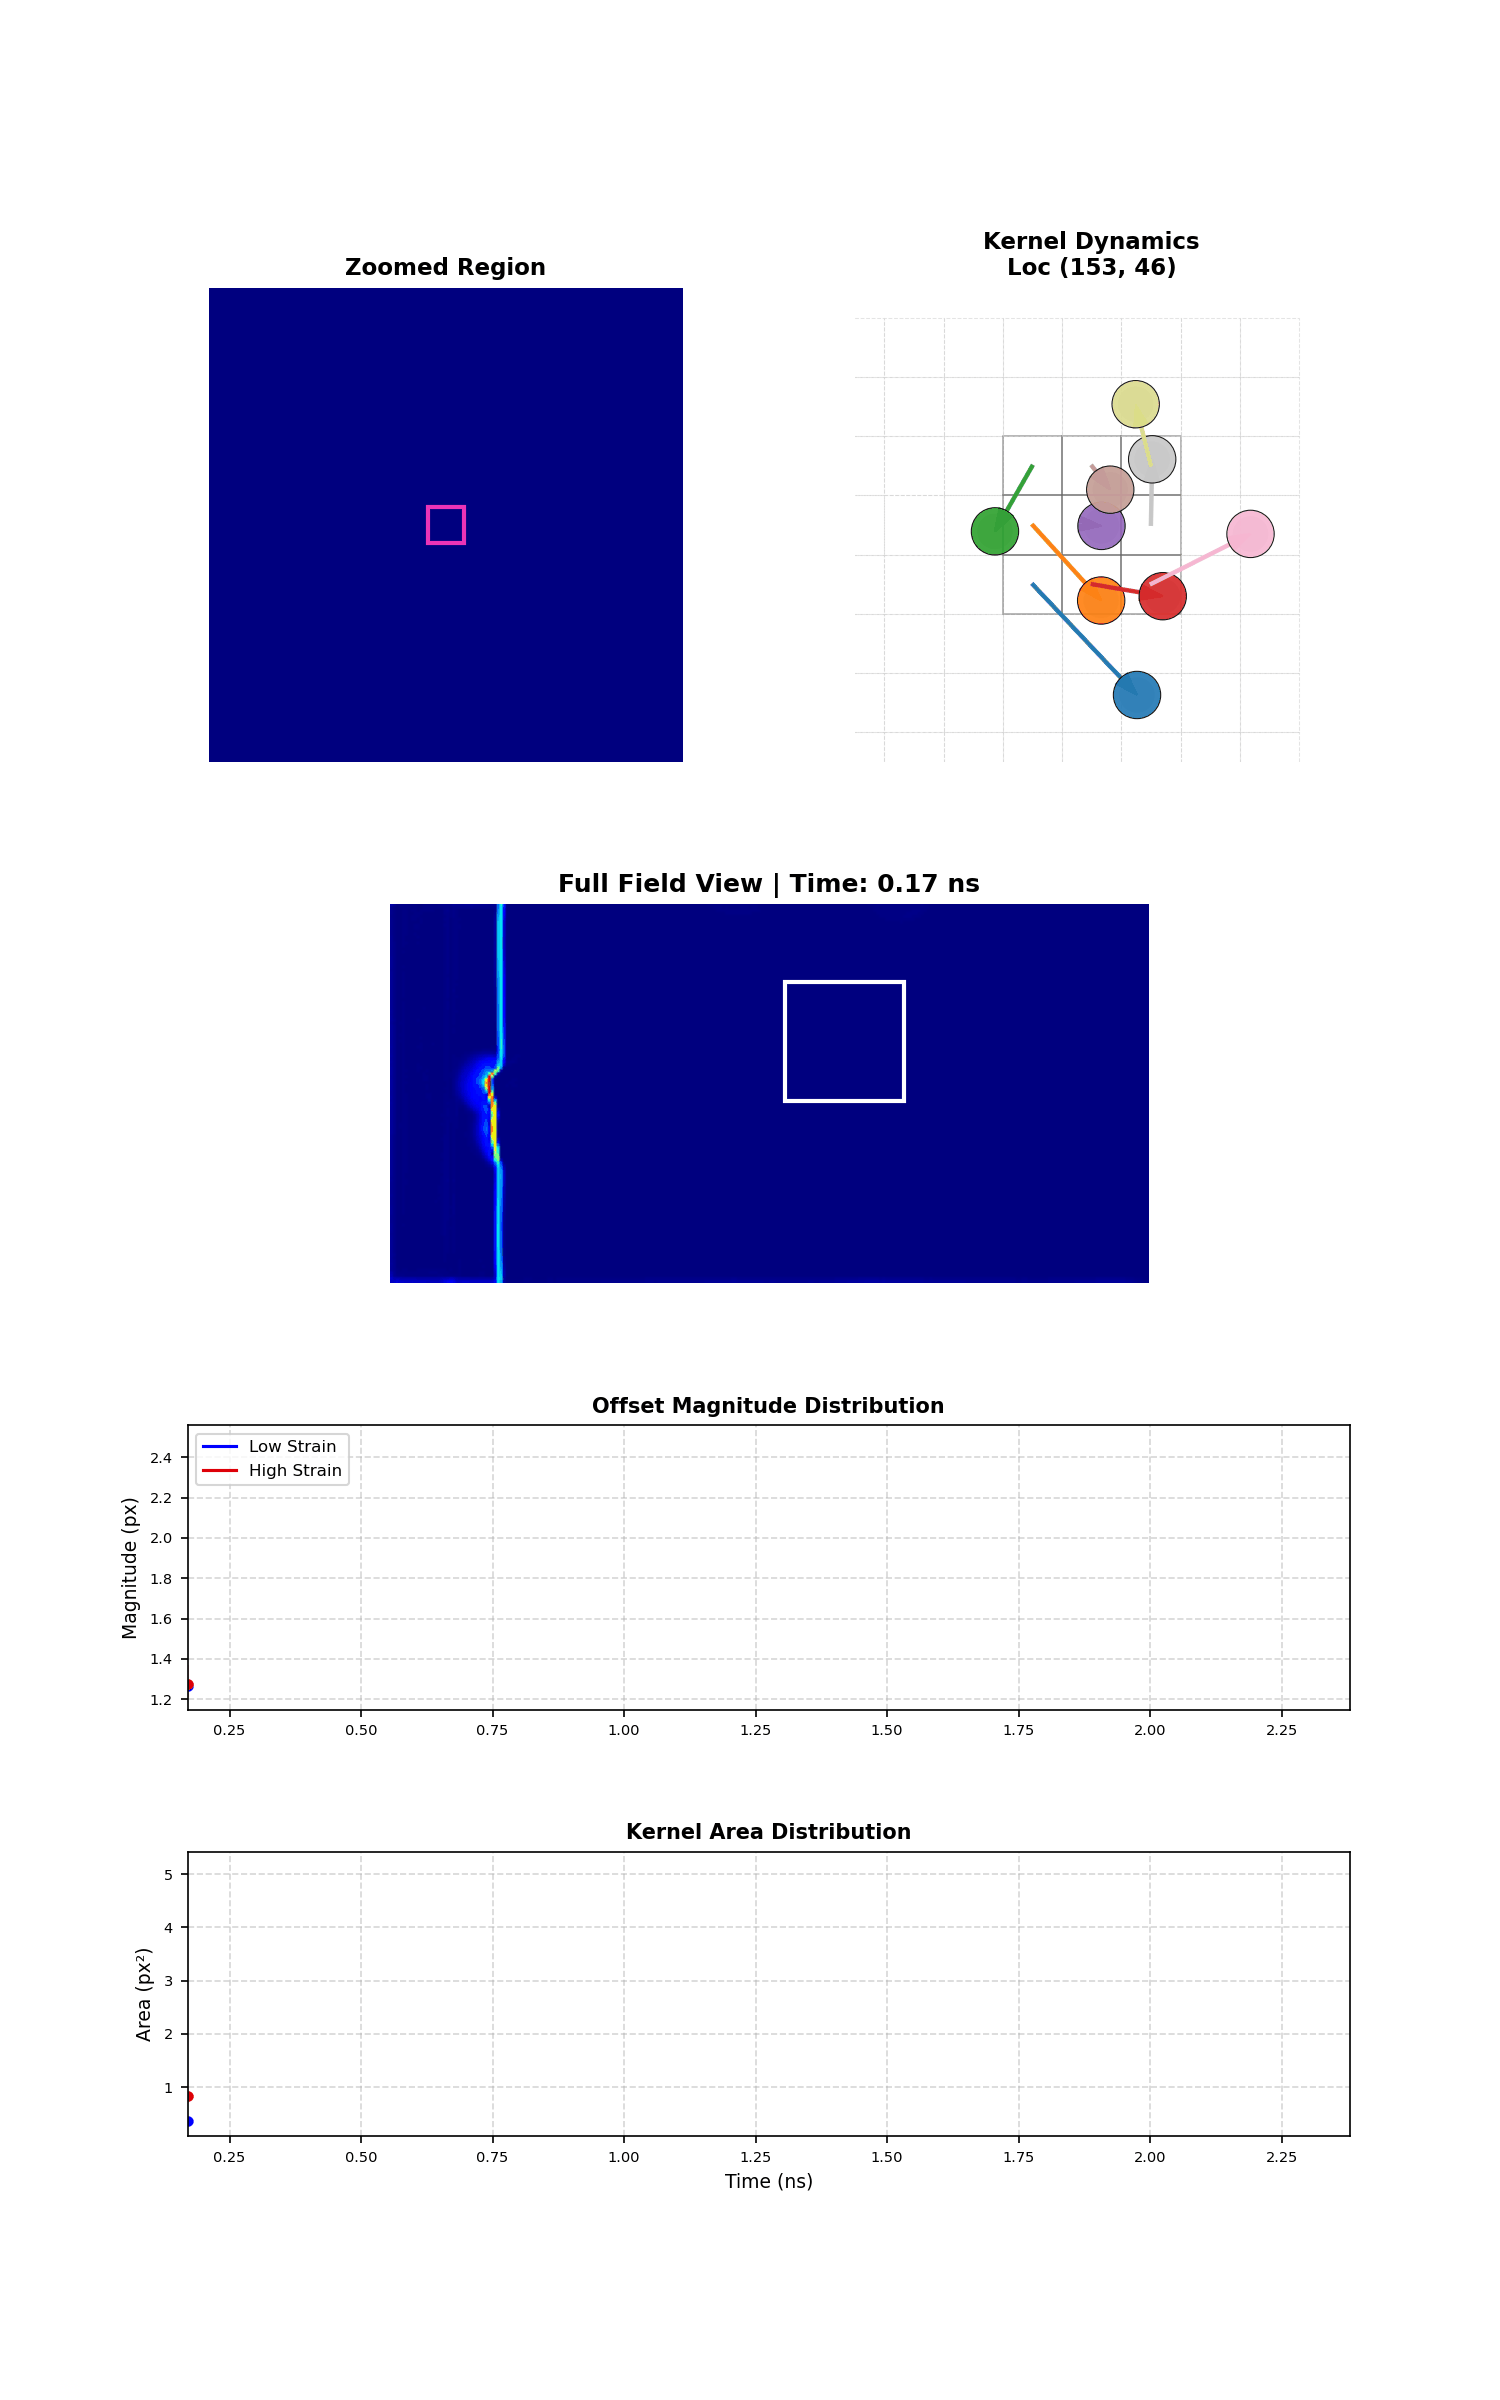

In [11]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration
# ------------------------------------------------------------------- #
TARGET_LOC_INDEX = 1   # (153, 46)
GIF_FPS = 1
GIF_OUTPUT_NAME = "deformable_kernel_dashboard_progressive.gif"
DT = 0.17
SPLIT_METRIC = "strain" # 'strain' or 'hotspot'
QUANTILES_TO_CALCULATE = [25, 50, 75]

# ------------------------------------------------------------------- #
# Part 1: Data Prep & Statistics Calculation (Global)
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run data loading first.")

all_timesteps_global = sorted(df['timestep'].unique())
stats_data_mag = {}
stats_data_area = {}

logging.info(f"Calculating global statistics using '{SPLIT_METRIC}'...")

# Pre-calculate global min/max for Y-axis scaling
global_mag_max = 0
global_area_max = 0

if SPLIT_METRIC == 'strain':
    graph_labels = {"low": "Low Strain", "high": "High Strain"}
    graph_colors = {"low": "blue", "high": "red"}
    
    for ts in all_timesteps_global:
        ts_df_global = df[df['timestep'] == ts]
        if ts_df_global.empty: continue
        stats_data_mag[ts] = {}
        stats_data_area[ts] = {}
        
        if 'strain_category' not in ts_df_global.columns: continue
            
        for cat_label, data_group in ts_df_global.groupby('strain_category'):
            data_mag = data_group['deformation_magnitude']
            data_area = data_group['ellipse_area']
            
            # Track Max for Y-limits
            if not data_mag.empty: global_mag_max = max(global_mag_max, data_mag.max())
            if not data_area.empty: global_area_max = max(global_area_max, data_area.max())

            for q in QUANTILES_TO_CALCULATE:
                stats_data_mag[ts][f"{cat_label}_q{q}"] = np.quantile(data_mag, q/100) if not data_mag.empty else np.nan
                stats_data_area[ts][f"{cat_label}_q{q}"] = np.quantile(data_area, q/100) if not data_area.empty else np.nan

# ------------------------------------------------------------------- #
# Part 2: Local Data Extraction
# ------------------------------------------------------------------- #
sample_df = df[df['sample_id'] == SAMPLE_ID].copy()
sample_timesteps = sorted(sample_df['timestep'].unique())
full_preds_by_ts = {}
full_offsets_by_ts = {}

spatial_locs = list(zip(SPATIAL_LOCATIONS[::2], SPATIAL_LOCATIONS[1::2]))
target_x, target_y = spatial_locs[TARGET_LOC_INDEX]
offset_cols = [f'offset_k{i}_d{ax}' for i in range(9) for ax in ['y', 'x']]

for ts in sample_timesteps:
    ts_df = sample_df[sample_df['timestep'] == ts]
    if ts_df.empty: continue
    full_preds_by_ts[ts] = ts_df.pivot_table(index='pixel_y', columns='pixel_x', values=VISUALIZATION_METRIC).values
    loc_row = ts_df[(ts_df['pixel_y'] == target_y) & (ts_df['pixel_x'] == target_x)]
    if not loc_row.empty:
        offsets_flat = loc_row[offset_cols].values[0]
        full_offsets_by_ts[ts] = np.stack([offsets_flat[::2], offsets_flat[1::2]], axis=-1)
    else:
        full_offsets_by_ts[ts] = np.zeros((9, 2))

# ------------------------------------------------------------------- #
# Part 3: Progressive Dashboard Animation
# ------------------------------------------------------------------- #
def generate_progressive_dashboard(target_loc_idx, display_channels_by_ts, offset_dict, 
                                   sample_ts_list, layer_key, output_path):
    
    # Layout: 4 Rows
    # Row 1: Zoom | Kernel
    # Row 2: Full Map
    # Row 3: Stats Mag (Full Width)
    # Row 4: Stats Area (Full Width)
    fig = plt.figure(figsize=(10, 16), dpi=150)
    gs = gridspec.GridSpec(4, 2, height_ratios=[1, 0.8, 0.6, 0.6], hspace=0.4, wspace=0.25)
    
    ax_zoom = fig.add_subplot(gs[0, 0])
    ax_kernel = fig.add_subplot(gs[0, 1])
    ax_full = fig.add_subplot(gs[1, :])
    ax_stat_mag = fig.add_subplot(gs[2, :])
    ax_stat_area = fig.add_subplot(gs[3, :])
    
    # Constants
    cmap = "jet"
    zoom_radius = 20
    kernel_zoom_lim = zoom_limits.get(layer_key, 4)
    H_offset, W_offset = next(iter(display_channels_by_ts.values())).shape
    target_x, target_y = spatial_locs[target_loc_idx]
    
    # Stats X-Axis Setup
    ts_global_sorted = sorted(stats_data_mag.keys())
    x_int = np.array(ts_global_sorted)
    min_ts = x_int.min()
    x_time_global = 0.17 + (x_int - min_ts) * 0.17
    
    # Baseline offsets
    initial_ts = sample_ts_list[0]
    baseline_offsets = offset_dict.get(initial_ts, np.zeros((9, 2)))

    def plot_progressive_stats(ax, stats_dict, title, ylabel, current_time_ns):
        ax.set_title(title, fontsize=10, weight='bold')
        ax.set_ylabel(ylabel, fontsize=9)
        if "Area" in title: ax.set_xlabel("Time (ns)", fontsize=9)
        
        # Lock Axis Limits so the graph doesn't jump
        ax.set_xlim(x_time_global.min(), x_time_global.max())
        # Use simple heuristics for Y-limits or pre-calc maxima
        # (Auto-scaling is tricky with partial data, so we rely on matplotlib defaults 
        # but force them to be stable by plotting invisible full data first)
        
        # 1. Plot INVISIBLE full data to establish scale
        for cat_key in graph_labels.keys():
             if not any(f"{cat_key}_q75" in stats_dict[t] for t in ts_global_sorted): continue
             q75_full = [stats_dict[t].get(f"{cat_key}_q75", np.nan) for t in ts_global_sorted]
             ax.plot(x_time_global, q75_full, alpha=0) 

        # 2. Slice Data for Progressive Reveal
        # Find index where time <= current_time_ns
        mask = x_time_global <= (current_time_ns + 0.01) # small epsilon
        x_visible = x_time_global[mask]
        
        # 3. Plot Visible Data
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_dict[t] for t in ts_global_sorted): continue
            
            # Extract full arrays first
            q50_all = np.array([stats_dict[t].get(f"{cat_key}_q50", np.nan) for t in ts_global_sorted])
            q25_all = np.array([stats_dict[t].get(f"{cat_key}_q25", np.nan) for t in ts_global_sorted])
            q75_all = np.array([stats_dict[t].get(f"{cat_key}_q75", np.nan) for t in ts_global_sorted])
            
            # Slice
            q50_vis = q50_all[mask]
            q25_vis = q25_all[mask]
            q75_vis = q75_all[mask]
            
            if len(x_visible) > 0:
                color = graph_colors.get(cat_key, 'black')
                ax.plot(x_visible, q50_vis, color=color, lw=1.5, label=label)
                ax.fill_between(x_visible, q25_vis, q75_vis, color=color, alpha=0.2)
                
                # Add a dot at the leading edge
                ax.plot(x_visible[-1], q50_vis[-1], marker='o', color=color, markersize=4)

        ax.grid(True, linestyle='--', alpha=0.5)
        if "Magnitude" in title: ax.legend(loc='upper left', fontsize=8)

    def update(frame_idx):
        ts = sample_ts_list[frame_idx]
        current_time_ns = (ts + 1) * DT
        ts_str = f"{current_time_ns:.2f} ns"
        
        for ax in [ax_zoom, ax_kernel, ax_full, ax_stat_mag, ax_stat_area]: ax.clear()
            
        pred_channel = display_channels_by_ts[ts]

        # --- Row 1 Left: Zoom ---
        ax_zoom.imshow(pred_channel, cmap=cmap, origin='upper', extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        ax_zoom.set_xlim(target_x - zoom_radius, target_x + zoom_radius)
        ax_zoom.set_ylim(target_y + zoom_radius, target_y - zoom_radius)
        ax_zoom.add_patch(Rectangle((target_x - 1.5, target_y - 1.5), 3, 3, lw=2, ec='#eb34b7', fc='none'))
        ax_zoom.set_title("Zoomed Region", fontsize=11, weight='bold')
        ax_zoom.axis('off')

        # --- Row 1 Right: Kernel ---
        ax_kernel.set_aspect('equal')
        ax_kernel.set_xlim(-kernel_zoom_lim, kernel_zoom_lim)
        ax_kernel.set_ylim(-kernel_zoom_lim, kernel_zoom_lim)
        ax_kernel.axis("off")
        grid_range = int(np.ceil(kernel_zoom_lim))
        for x_g in range(-grid_range, grid_range):
            for y_g in range(-grid_range, grid_range):
                is_central = -1 <= x_g < 2 and -1 <= y_g < 2
                ax_kernel.add_patch(Rectangle((x_g - 0.5, y_g - 0.5), 1, 1, lw=0.75 if is_central else 0.5, 
                                            ec='dimgray' if is_central else 'lightgray', fc='none', ls='-' if is_central else '--', alpha=0.6))
        
        current_offsets = offset_dict.get(ts, np.zeros((9, 2)))
        for i_el in range(9):
            start_point = grid_coords[i_el]
            # Ghost Baseline
            base_yx = baseline_offsets[i_el]
            base_vec = np.array([base_yx[1], -base_yx[0]])
            ax_kernel.add_patch(Circle(start_point + base_vec, radius=0.3, lw=0, fc='silver', alpha=0.5))
            if np.linalg.norm(base_vec) > 0.01:
                 ax_kernel.arrow(start_point[0], start_point[1], base_vec[0], base_vec[1], head_width=0.2, width=0.03, fc='silver', ec='silver', alpha=0.5, length_includes_head=True)
            # Current
            curr_yx = current_offsets[i_el]
            curr_vec = np.array([curr_yx[1], -curr_yx[0]])
            if np.linalg.norm(curr_vec) > 0.01: 
                ax_kernel.arrow(start_point[0], start_point[1], curr_vec[0], curr_vec[1], head_width=0.25, width=0.04, fc=kernel_colors[i_el], ec=kernel_colors[i_el], alpha=0.9, length_includes_head=True)
            ax_kernel.add_patch(Circle(start_point + curr_vec, radius=0.4, lw=0.5, ec='k', fc=kernel_colors[i_el], alpha=0.9))
        ax_kernel.set_title(f"Kernel Dynamics\nLoc ({target_x}, {target_y})", fontsize=11, weight='bold')

        # --- Row 2: Full Map ---
        ax_full.imshow(pred_channel, cmap=cmap, origin='upper', extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        ax_full.add_patch(Rectangle((target_x - zoom_radius, target_y - zoom_radius), zoom_radius*2, zoom_radius*2, lw=2, ec='white', fc='none'))
        ax_full.set_title(f"Full Field View | Time: {ts_str}", fontsize=12, weight='bold')
        ax_full.axis('off')
        
        # --- Rows 3 & 4: Progressive Stats ---
        plot_progressive_stats(ax_stat_mag, stats_data_mag, "Offset Magnitude Distribution", "Magnitude (px)", current_time_ns)
        plot_progressive_stats(ax_stat_area, stats_data_area, "Kernel Area Distribution", "Area (px²)", current_time_ns)

    print(f"Generating Progressive Dashboard GIF for {len(sample_ts_list)} frames...")
    ani = animation.FuncAnimation(fig, update, frames=len(sample_ts_list), interval=600)
    
    out_file = Path(OUTPUT_DIR) / GIF_OUTPUT_NAME
    ani.save(out_file, writer=PillowWriter(fps=GIF_FPS))
    plt.close(fig)
    return out_file

# ------------------------------------------------------------------- #
# Execution
# ------------------------------------------------------------------- #
layer_name = Path(CSV_PATH).stem.split('_unified_data')[0].split('_')[-1]

gif_path = generate_progressive_dashboard(
    TARGET_LOC_INDEX, 
    full_preds_by_ts, 
    full_offsets_by_ts,
    sample_timesteps, 
    layer_name,
    OUTPUT_DIR
)

print(f"Dashboard saved: {gif_path}")
display(Image(filename=gif_path))

2025-10-10 14:27:34,898 [INFO] Calculating statistics for Panels A & B using 'strain' metric...
/tmp/ipykernel_235694/1341850897.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_235694/1341850897.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure 2 (A-B) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/hmx_scripts/em_combined_vis_from_notebook/fig2_ab_3_sample16_strain.pdf`

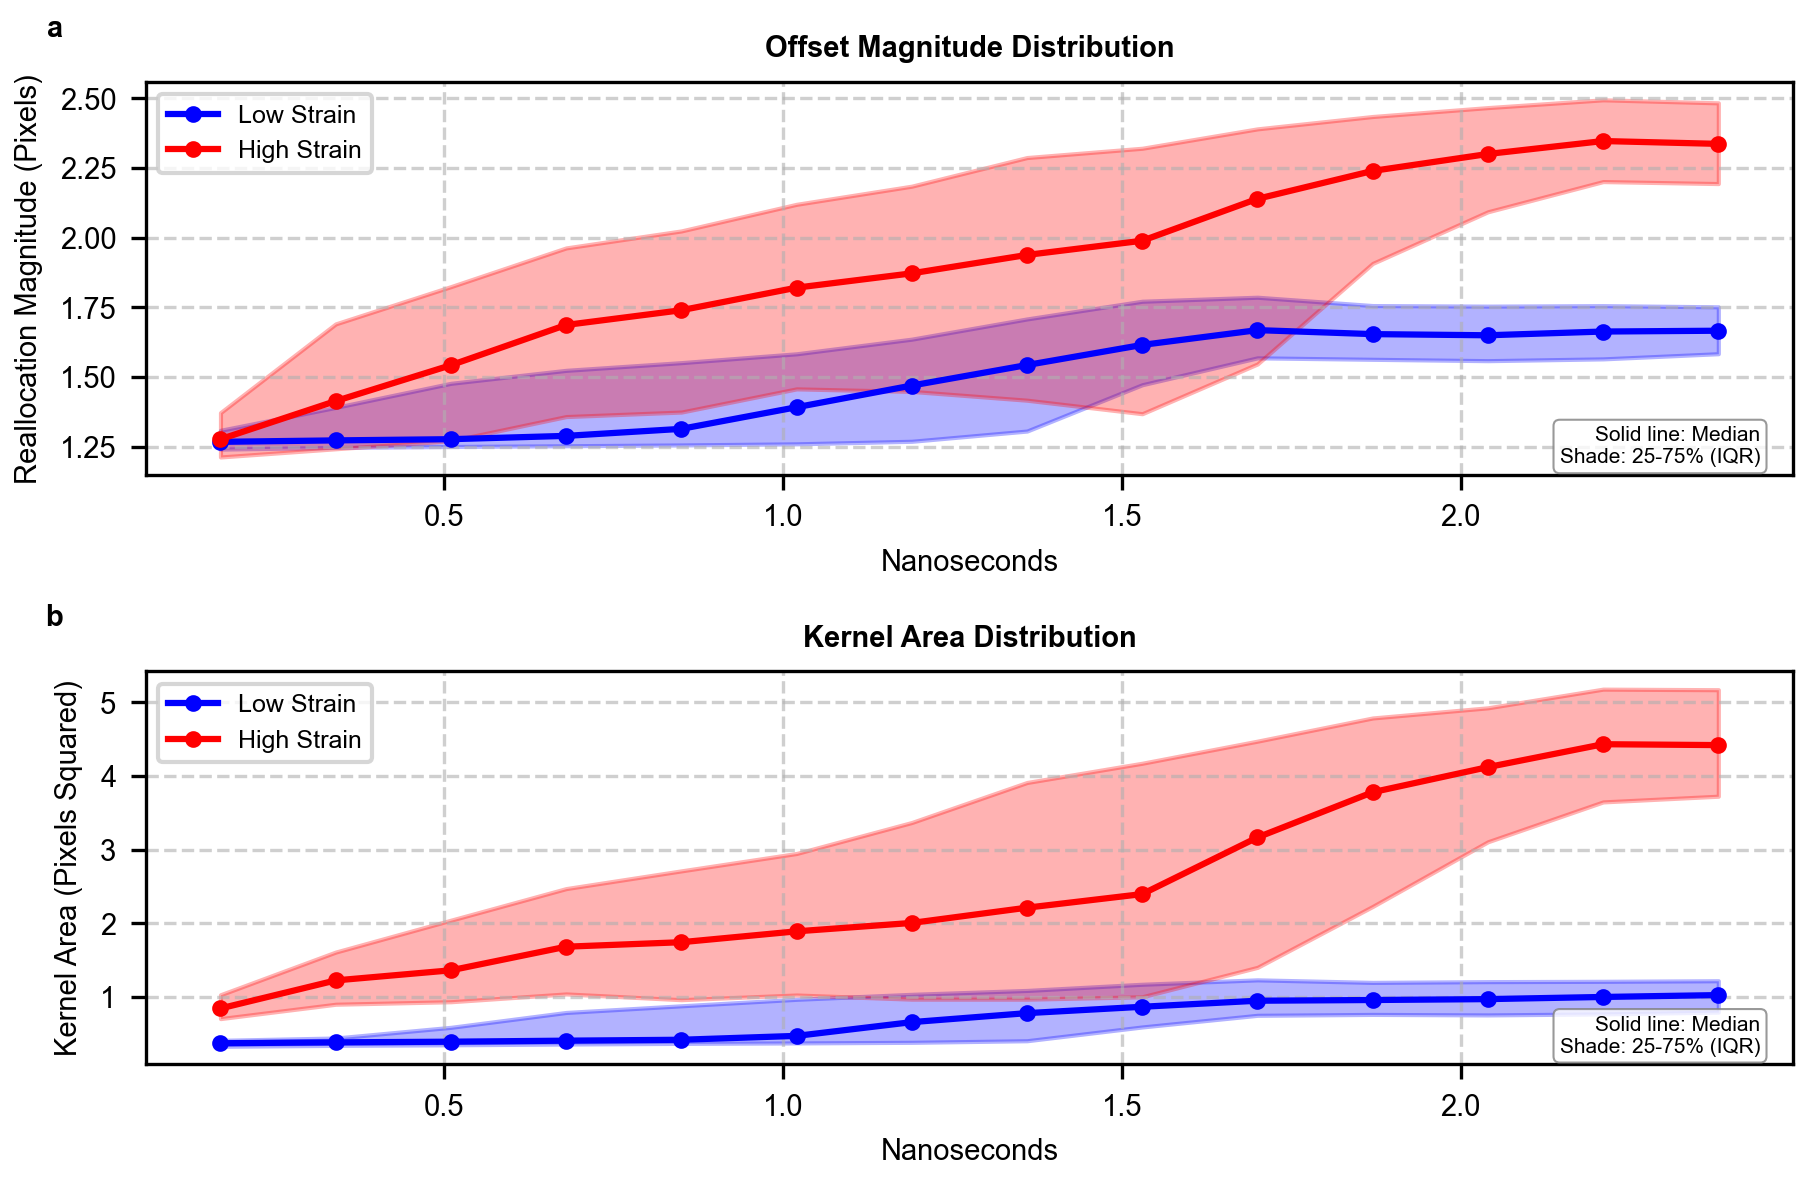

In [34]:
#!/usr/bin/env python3
"""
Figure 2: Panels A and B - Statistical Distributions
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "em_combined_vis_from_notebook"
SPLIT_METRIC = "strain"  # 'strain' or 'hotspot'
SAMPLE_ID = 16

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell (Cell 1) first.")

def set_publication_style():
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, output_path):
    set_publication_style()
    
    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * 0.6  # Increased from 0.4 for larger plots
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.5)  # Increased from 0.35 for more separation
    
    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    quantiles_to_plot = [25, 50, 75]

    # Panel A: Offset Magnitude (was Panel E)
    ax_graph_a = fig.add_subplot(gs[0, 0])
    ax_graph_a.text(-0.05, 1.1, 'a', transform=ax_graph_a.transAxes, **label_props)
    ax_graph_a.set_title("Offset Magnitude Distribution", fontsize=7, weight='bold')
    ts_data_mag = sorted(stats_data_mag.keys())
    if ts_data_mag:
        # MODIFIED: Convert integer timesteps to nanoseconds for the x-axis
        x_int = np.array(ts_data_mag)
        min_ts = x_int.min()
        x = 0.17 + (x_int - min_ts) * 0.17
        
        color_map_cats = {"low": "blue", "high": "red", "hotspot": "red", "non_hotspot": "blue"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_mag[t] for t in ts_data_mag): continue
            quantiles = {f'q{q}': np.array([stats_data_mag[t].get(f"{cat_key}_q{q}", np.nan) 
                                            for t in ts_data_mag]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_a.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                            marker='o', markersize=3)
            ax_graph_a.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_a.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                    transform=ax_graph_a.transAxes, fontsize=5, verticalalignment='bottom', 
                    horizontalalignment='right', 
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))
    
    # MODIFIED: Updated x-axis label
    ax_graph_a.set_xlabel("Nanoseconds")
    ax_graph_a.set_ylabel("Reallocation Magnitude (Pixels)")
    ax_graph_a.legend(loc='best')
    ax_graph_a.grid(True, linestyle='--', alpha=0.6)

    # Panel B: Kernel Area (was Panel F)
    ax_graph_b = fig.add_subplot(gs[1, 0])
    ax_graph_b.text(-0.05, 1.1, 'b', transform=ax_graph_b.transAxes, **label_props)
    ax_graph_b.set_title("Kernel Area Distribution", fontsize=7, weight='bold')
    ts_data_area = sorted(stats_data_area.keys())
    if ts_data_area:
        # MODIFIED: Convert integer timesteps to nanoseconds for the x-axis
        x_int = np.array(ts_data_area)
        min_ts = x_int.min()
        x = 0.17 + (x_int - min_ts) * 0.17
        
        color_map_cats = {"low": "blue", "high": "red", "hotspot": "red", "non_hotspot": "blue"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_area[t] for t in ts_data_area): continue
            quantiles = {f'q{q}': np.array([stats_data_area[t].get(f"{cat_key}_q{q}", np.nan) 
                                            for t in ts_data_area]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_b.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                            marker='o', markersize=3)
            ax_graph_b.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_b.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                    transform=ax_graph_b.transAxes, fontsize=5, verticalalignment='bottom', 
                    horizontalalignment='right', 
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))

    # MODIFIED: Updated x-axis label
    ax_graph_b.set_xlabel("Nanoseconds")
    ax_graph_b.set_ylabel("Kernel Area (Pixels Squared)")
    ax_graph_b.legend(loc='best')
    ax_graph_b.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
QUANTILES_TO_CALCULATE = [25, 50, 75]

# Calculate statistics on GLOBAL dataframe
all_timesteps_global = sorted(df['timestep'].unique())
stats_data_mag = {}
stats_data_area = {}
logging.info(f"Calculating statistics for Panels A & B using '{SPLIT_METRIC}' metric...")

if SPLIT_METRIC == 'strain':
    graph_labels = {"low": "Low Strain", "high": "High Strain"}
    for ts in all_timesteps_global:
        ts_df_global = df[df['timestep'] == ts]
        if ts_df_global.empty: continue
        stats_data_mag[ts] = {}
        stats_data_area[ts] = {}
        for cat_label, data_group in ts_df_global.groupby('strain_category'):
            data_mag = data_group['deformation_magnitude']
            stats_data_mag[ts][f"{cat_label}_q25"] = np.quantile(data_mag, 0.25) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q50"] = np.quantile(data_mag, 0.50) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q75"] = np.quantile(data_mag, 0.75) if not data_mag.empty else np.nan
            
            data_area = data_group['ellipse_area']
            stats_data_area[ts][f"{cat_label}_q25"] = np.quantile(data_area, 0.25) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q50"] = np.quantile(data_area, 0.50) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q75"] = np.quantile(data_area, 0.75) if not data_area.empty else np.nan
else:  # 'hotspot'
    graph_labels = {"hotspot": "Hotspot (T≥875K)", "non_hotspot": "Non-Hotspot"}
    for ts in all_timesteps_global:
        ts_df_global = df[df['timestep'] == ts]
        if ts_df_global.empty: continue
        stats_data_mag[ts] = {}
        stats_data_area[ts] = {}
        hotspot_mask = ts_df_global['Temperature (T)'] >= 875
        data_map_mag = {
            "hotspot": ts_df_global[hotspot_mask]['deformation_magnitude'], 
            "non_hotspot": ts_df_global[~hotspot_mask]['deformation_magnitude']
        }
        data_map_area = {
            "hotspot": ts_df_global[hotspot_mask]['ellipse_area'], 
            "non_hotspot": ts_df_global[~hotspot_mask]['ellipse_area']
        }
        for cat_label in data_map_mag.keys():
            data_mag = data_map_mag[cat_label]
            data_area = data_map_area[cat_label]
            for q in QUANTILES_TO_CALCULATE:
                stats_data_mag[ts][f"{cat_label}_q{q}"] = np.quantile(data_mag, q / 100.0) if not data_mag.empty else np.nan
                stats_data_area[ts][f"{cat_label}_q{q}"] = np.quantile(data_area, q / 100.0) if not data_area.empty else np.nan

# Generate figure
layer_name = Path(CSV_PATH).stem.split('_unified_data')[0].split('_')[-1]
out_file_pdf = Path(OUTPUT_DIR) / f"fig2_ab_{layer_name}_sample{SAMPLE_ID}_{SPLIT_METRIC}.pdf"
out_file_png = out_file_pdf.with_suffix('.png')

generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_pdf)
generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_png)

display(Markdown(f"### Figure 2 (A-B) saved to: `{out_file_pdf.resolve()}`"))
display(Image(filename=out_file_png))

In [18]:
################################################################################
# CELL 1: Load NS Data and Perform Global Clustering (Run this cell only once)
################################################################################

#!/usr/bin/env python3
"""
CELL 1: Data Loading and Global Processing for Navier-Stokes Data

This cell loads the unified CSV data file for the NS dataset and performs
global K-Means clustering. It should be run once to make the processed data
available for the visualization cell that follows.
"""

import pandas as pd
from pathlib import Path
import logging
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
import numpy as np

# ------------------------------------------------------------------- #
# Configuration - EDIT THIS VALUE
# ------------------------------------------------------------------- #
# Path to the unified data CSV file for the Navier-Stokes dataset.
CSV_PATH = '/home/jtb3sud/PARCtorch/PARCtorch/scripts/eval_results/ns/perpixel_job_2637670/ns_upBlock_3_per_pixel_analysis.csv'

# --- Setup ---
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

# --- Load and Process Data from CSV ---
display(Markdown(f"### Loading data from `{CSV_PATH}`..."))
try:
    df = pd.read_csv(CSV_PATH)
    display(Markdown(f"**Successfully loaded data with {len(df)} rows.**"))
    
    # --- Perform global K-Means clustering on the ENTIRE dataframe ---
    if 'strain_rate_magnitude' in df.columns:
        logging.info("Performing global K-Means clustering on the entire CSV's strain data...")
        strain_values = df[['strain_rate_magnitude']].values
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(strain_values)
        centers = kmeans.cluster_centers_.flatten()
        label_map = {np.argmin(centers): "low", np.argmax(centers): "high"}
        df['strain_category'] = kmeans.predict(strain_values)
        df['strain_category'] = df['strain_category'].map(label_map)
        logging.info("Global clustering complete. 'strain_category' column added.")
    
    display(df.head())
    
    available_samples = sorted(df['sample_id'].unique())
    display(Markdown(f"**Available `sample_id` values:** `{available_samples}`"))
    
except FileNotFoundError:
    logging.error(f"Error: CSV file not found at {CSV_PATH}")
    df = None

### Loading data from `/home/jtb3sud/PARCtorch/PARCtorch/scripts/eval_results/ns/perpixel_job_2637670/ns_upBlock_3_per_pixel_analysis.csv`...

**Successfully loaded data with 9688480 rows.**

2025-10-11 15:38:38,281 [INFO] Performing global K-Means clustering on the entire CSV's strain data...
2025-10-11 15:38:59,525 [INFO] Global clustering complete. 'strain_category' column added.


,anisotropy,orientation,ellipse_area,shear_magnitude,deformation_magnitude,centroid_skew_magnitude,sample_id,timestep,pixel_y,pixel_x,...,offset_k4_dx,offset_k5_dy,offset_k5_dx,offset_k6_dy,offset_k6_dx,offset_k7_dy,offset_k7_dx,offset_k8_dy,offset_k8_dx,strain_category
0,3.34361,87.1131,0.935474,0.027140,0.807654,0.74902,0,0,0,0,...,0.057667,-0.715366,-0.329626,-1.25499,-0.028040,-1.24067,0.125807,-1.50844,-0.291383,low
1,5.17460,85.2268,0.435232,0.056064,1.279110,1.19428,0,0,0,1,...,0.023986,-1.120180,-0.592690,-2.08654,0.101521,-1.83277,-0.008946,-2.26641,-0.473785,low
2,5.48781,84.3870,0.419944,0.067333,1.317130,1.23149,0,0,0,2,...,0.017705,-1.147670,-0.606513,-2.12615,0.105714,-1.88764,-0.002543,-2.31747,-0.479135,low
3,5.65442,82.7135,0.421532,0.087995,1.318870,1.23326,0,0,0,3,...,0.017582,-1.144550,-0.595609,-2.12485,0.106857,-1.87483,-0.007174,-2.29843,-0.473742,low
4,5.76862,81.1002,0.423838,0.107681,1.318430,1.23302,0,0,0,4,...,0.018444,-1.140580,-0.584216,-2.11780,0.110680,-1.86170,-0.016792,-2.27471,-0.474484,low


**Available `sample_id` values:** `[0, 1, 2, 3, 4, 5, 6, 7]`

/tmp/ipykernel_310695/3179840885.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_310695/3179840885.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure A1 (A-D) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/hmx_scripts/ns_combined_vis_from_notebook/figA1_abcd_ns_upBlock_3_sample5_strain_rate_magnitude.pdf`

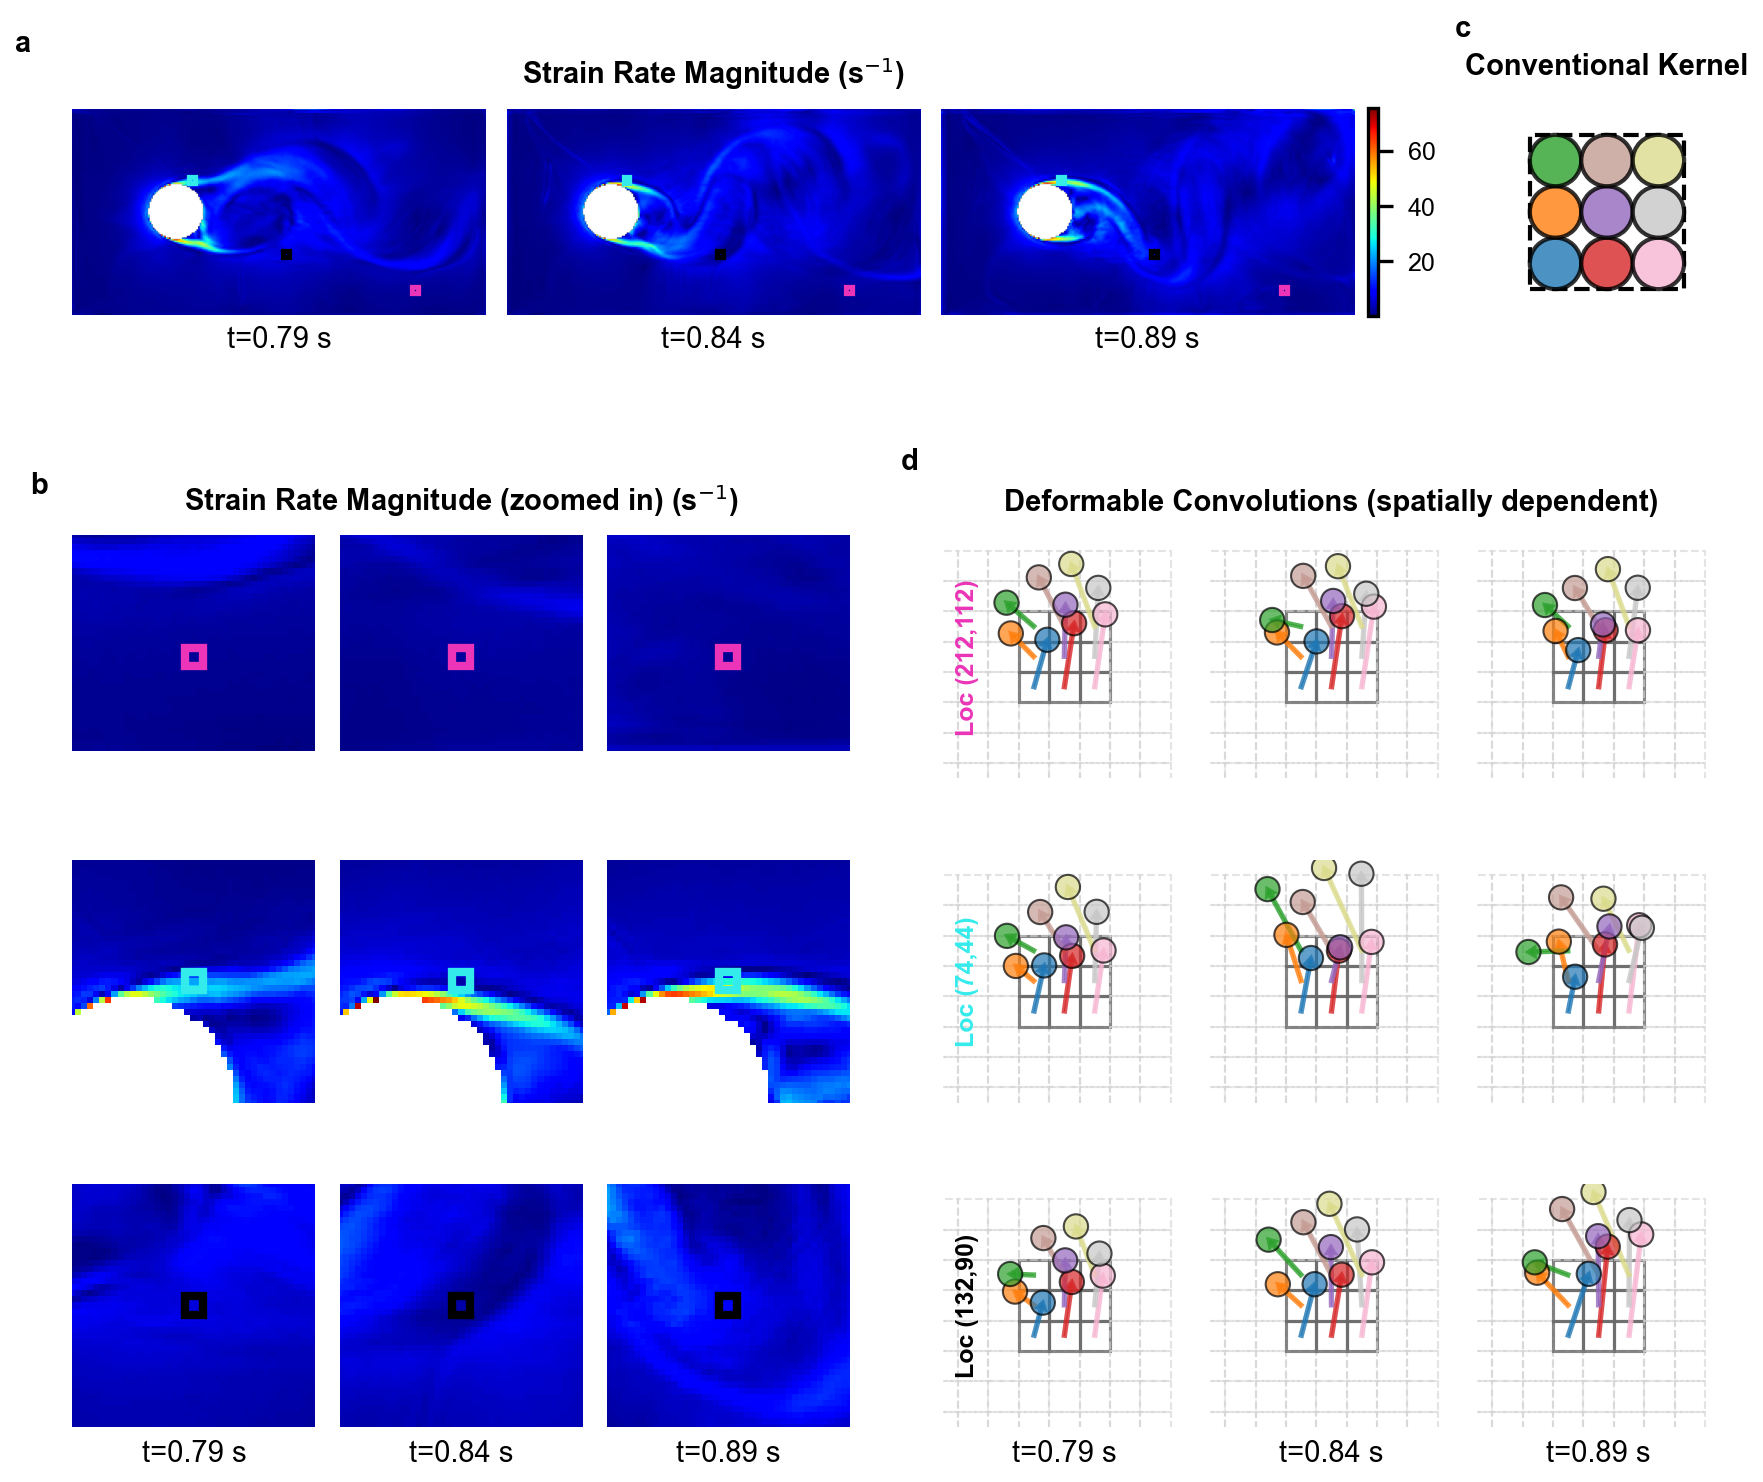

In [20]:
#!/usr/bin/env python3
"""
Figure A1: Panels A, B, C, D - Spatial Visualization for Navier-Stokes Data
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Circle
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "ns_combined_vis_from_notebook"
VISUALIZATION_METRIC = 'strain_rate_magnitude'
SPATIAL_LOCATIONS = [212, 112, 74, 44, 132, 90]
TIMESTEPS = [14, 15, 16]
SAMPLE_ID = 5

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell first.")
if 'CSV_PATH' not in globals():
    raise NameError("Variable 'CSV_PATH' not found. Please define it with the path to your data file.")

# Static variables
color_map = plt.get_cmap("tab20")
kernel_colors = [color_map(i) for i in np.linspace(0, 1, 9, endpoint=False)]
grid_coords = np.array([[-1,-1],[-1,0],[-1,1],[0,-1],[0,0],[0,1],[1,-1],[1,0],[1,1]], dtype=np.float32)
zoom_limits = {"initial_doubleConv": 3, "upBlock_3": 3}

def set_publication_style():
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_abcd_figure(spatial_locations, display_channels_by_ts, offset_fields_by_ts,
                         layer_key, output_path, title_prefix):
    set_publication_style()
    num_locations = len(spatial_locations)
    timesteps_to_plot = sorted(display_channels_by_ts.keys())
    num_ts = len(timesteps_to_plot)

    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * (0.28 * num_locations + 0.5)
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    
    gs_main = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, num_locations * 0.35], hspace=-0.46)
    a_c_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0],
                                              width_ratios=[num_ts, 0.5], wspace=0.08)
    a_gs = gridspec.GridSpecFromSubplotSpec(1, num_ts, subplot_spec=a_c_gs[0, 0], wspace=0.05)
    b_d_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1],
                                              width_ratios=[1, 1], wspace=0.12)
    
    b_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 0],
                                            wspace=0.1, hspace=-0.6)
    d_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 1],
                                            wspace=0.1, hspace=-0.6)

    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    cmap = "jet"
    rec_colors = ['#eb34b7', '#34ebeb', '#000000', '#34eb3d']
    H_offset, W_offset = next(iter(display_channels_by_ts.values())).shape

    # Panel A - Single title on middle subplot
    panel_a_axes = []
    panel_a_ims = []  # Store image objects for colorbar
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        ax_full_view = fig.add_subplot(a_gs[0, i])
        panel_a_axes.append(ax_full_view)
        im = ax_full_view.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        panel_a_ims.append(im)
        
        # Only show title on the middle subplot
        if i == 1:
            ax_full_view.set_title(f"{title_prefix} (s$^{{-1}}$)", fontsize=7, weight='bold')
        
        # Add time label at bottom - convert timestep to actual time
        # Formula: time = (timestep + 1) * 0.0526315789
        time_value = (ts + 1) * 0.0526315789
        ax_full_view.text(0.5, -0.05, f"t={time_value:.2f} s", transform=ax_full_view.transAxes,
                         ha='center', va='top', fontsize=7)
        
        ax_full_view.axis('off')
        if i == 0: 
            ax_full_view.text(-0.1, 1.25, 'a', transform=ax_full_view.transAxes, **label_props)
        for loc_idx, (cur_x, cur_y) in enumerate(spatial_locations):
            ax_full_view.add_patch(Rectangle((cur_x - 1.5, cur_y - 1.5), 3, 3, lw=1.5,
                                             ec=rec_colors[loc_idx % len(rec_colors)], fc='none'))
    
    # Add colorbar for Panel A (matching EM/Burgers formatting)
    cbar_a = fig.colorbar(panel_a_ims[-1], ax=panel_a_axes, fraction=0.046, pad=0.01, shrink=0.15)
    cbar_a.ax.tick_params(labelsize=6)

    # Panel B - Single title with "zoomed in" on middle subplot of top row
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        for zoom_idx, (zoom_loc_x, zoom_loc_y) in enumerate(spatial_locations):
            ax_zoom = fig.add_subplot(b_gs[zoom_idx, i])
            if zoom_idx == 0 and i == 1:
                ax_zoom.set_title(f"{title_prefix} (zoomed in) (s$^{{-1}}$)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if zoom_idx == num_locations - 1:
                # Convert timestep to actual time: time = (timestep + 1) * 0.0526315789
                time_value = (ts + 1) * 0.0526315789
                ax_zoom.text(0.5, -0.05, f"t={time_value:.2f} s", transform=ax_zoom.transAxes,
                           ha='center', va='top', fontsize=7)
            
            ax_zoom.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
            ax_zoom.set_xlim(zoom_loc_x - 20, zoom_loc_x + 20)
            ax_zoom.set_ylim(zoom_loc_y + 20, zoom_loc_y - 20)
            ax_zoom.set_aspect('equal', adjustable='box')
            ax_zoom.add_patch(Rectangle((zoom_loc_x - 1.5, zoom_loc_y - 1.5), 3, 3, lw=2,
                                        ec=rec_colors[zoom_idx % len(rec_colors)], fc='none'))
            ax_zoom.axis('off')
            if i == 0 and zoom_idx == 0:
                ax_zoom.text(-0.1, 1.15, 'b', transform=ax_zoom.transAxes, **label_props)

    # Panel C
    ax_conv_kernel = fig.add_subplot(a_c_gs[0, 1])
    ax_conv_kernel.set_title("Conventional Kernel", fontsize=7, weight='bold')
    ax_conv_kernel.set_aspect('equal', adjustable='box')
    ax_conv_kernel.set_xlim(-2.2, 2.2)
    ax_conv_kernel.set_ylim(-2.2, 2.2)
    ax_conv_kernel.axis("off")
    ax_conv_kernel.text(-0.1, 1.25, 'c', transform=ax_conv_kernel.transAxes, **label_props)
    ax_conv_kernel.add_patch(Rectangle((-1.5, -1.5), 3, 3, lw=1, ec='k', fc='none', linestyle='--'))
    for i_el in range(9):
        ax_conv_kernel.add_patch(Circle((grid_coords[i_el][0], grid_coords[i_el][1]),
                                        radius=0.5, lw=1, ec='k', fc=kernel_colors[i_el], alpha=0.8))

    # Panel D - Single title with "spatially dependent" on middle subplot of top row
    for i_loc, (cur_x, cur_y) in enumerate(spatial_locations):
        for j_ts, ts in enumerate(timesteps_to_plot):
            ax_def = fig.add_subplot(d_gs[i_loc, j_ts])
            if i_loc == 0 and j_ts == 1:
                ax_def.set_title("Deformable Convolutions (spatially dependent)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if i_loc == num_locations - 1:
                # Convert timestep to actual time: time = (timestep + 1) * 0.0526315789
                time_value = (ts + 1) * 0.0526315789
                ax_def.text(0.5, -0.05, f"t={time_value:.2f} s", transform=ax_def.transAxes,
                          ha='center', va='top', fontsize=7)
            
            if i_loc == 0 and j_ts == 0:
                ax_def.text(-0.1, 1.25, 'd', transform=ax_def.transAxes, **label_props)
            zoom_lim = zoom_limits.get(layer_key, 4)
            if j_ts == 0:
                ax_def.text(-zoom_lim * 0.8, 0, f"Loc ({cur_x},{cur_y})", rotation=90, size=6,
                            ha='center', va='center',
                            color=rec_colors[i_loc % len(rec_colors)], fontweight='bold')
            ax_def.set_aspect('equal', adjustable='box')
            ax_def.set_xlim(-zoom_lim, zoom_lim)
            ax_def.set_ylim(-zoom_lim, zoom_lim)
            ax_def.axis("off")
            grid_range = int(np.ceil(zoom_lim))
            for x_g in range(-grid_range, grid_range):
                for y_g in range(-grid_range, grid_range):
                    is_central = -1 <= x_g < 2 and -1 <= y_g < 2
                    ax_def.add_patch(Rectangle((x_g - 0.5, y_g - 0.5), 1, 1,
                                               lw=0.75 if is_central else 0.5,
                                               ec='dimgray' if is_central else 'lightgray',
                                               fc='none', ls='-' if is_central else '--',
                                               alpha=0.8 if is_central else 0.6))
            offsets_at_loc = offset_fields_by_ts.get(ts, {}).get((cur_y, cur_x), np.zeros((9, 2)))
            for i_el in range(9):
                offset_yx = offsets_at_loc[i_el]
                offset_vec = np.array([offset_yx[1], -offset_yx[0]])  # Negate y for correct direction
                start_point = grid_coords[i_el]
                endpoint = start_point + offset_vec
                
                # Draw colored vector for the offset
                if np.linalg.norm(offset_vec) > 0.01:
                    ax_def.arrow(start_point[0], start_point[1],
                                 offset_vec[0], offset_vec[1],
                                 head_width=0.25, head_length=0.2,
                                 width=0.04, fc=kernel_colors[i_el],
                                 ec=kernel_colors[i_el], alpha=0.8,
                                 length_includes_head=True)
                
                ax_def.add_patch(Circle((endpoint[0], endpoint[1]), radius=0.4,
                                        lw=0.5, ec='k', fc=kernel_colors[i_el], alpha=0.7, zorder=10))

    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
spatial_locs = list(zip(SPATIAL_LOCATIONS[::2], SPATIAL_LOCATIONS[1::2]))

sample_df = df[df['sample_id'] == SAMPLE_ID].copy()
if sample_df.empty:
    logging.error(f"No data found for sample_id {SAMPLE_ID}.")
else:
    offsets_by_ts, preds_by_ts = {}, {}
    for ts in TIMESTEPS:
        ts_df = sample_df[sample_df['timestep'] == ts]
        if ts_df.empty: continue
        preds_by_ts[ts] = ts_df.pivot_table(index='pixel_y', columns='pixel_x', values=VISUALIZATION_METRIC).values
        offset_cols = [f'offset_k{i}_d{ax}' for i in range(9) for ax in ['y', 'x']]
        loc_df = ts_df.set_index(['pixel_y', 'pixel_x'])
        offsets_by_ts[ts] = {}
        for x, y in spatial_locs:
            if (y, x) in loc_df.index:
                offsets_flat = loc_df.loc[(y, x), offset_cols].values
                offsets_by_ts[ts][(y, x)] = np.stack([offsets_flat[::2], offsets_flat[1::2]], axis=-1)

    if preds_by_ts:
        layer_name = Path(CSV_PATH).stem.split('_per_pixel_analysis')[0]
        clean_metric_name = VISUALIZATION_METRIC.replace(" ", "_").replace("(", "").replace(")", "")
        out_file_pdf = Path(OUTPUT_DIR) / f"figA1_abcd_{layer_name}_sample{SAMPLE_ID}_{clean_metric_name}.pdf"
        out_file_png = out_file_pdf.with_suffix('.png')
        
        # Use "Strain Rate" as the title instead of "Strain Rate Magnitude"
        title_prefix = "Strain Rate Magnitude"

        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_pdf, title_prefix)
        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_png, title_prefix)

        display(Markdown(f"### Figure A1 (A-D) saved to: `{out_file_pdf.resolve()}`"))
        display(Image(filename=out_file_png))

2025-10-11 15:50:51,589 [INFO] Calculating statistics for Panels A & B using 'strain' metric...
/tmp/ipykernel_310695/3318749159.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_310695/3318749159.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure A2 (A-B) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/hmx_scripts/ns_combined_vis_from_notebook/figA2_ab_ns_upBlock_3_sample7_strain.pdf`

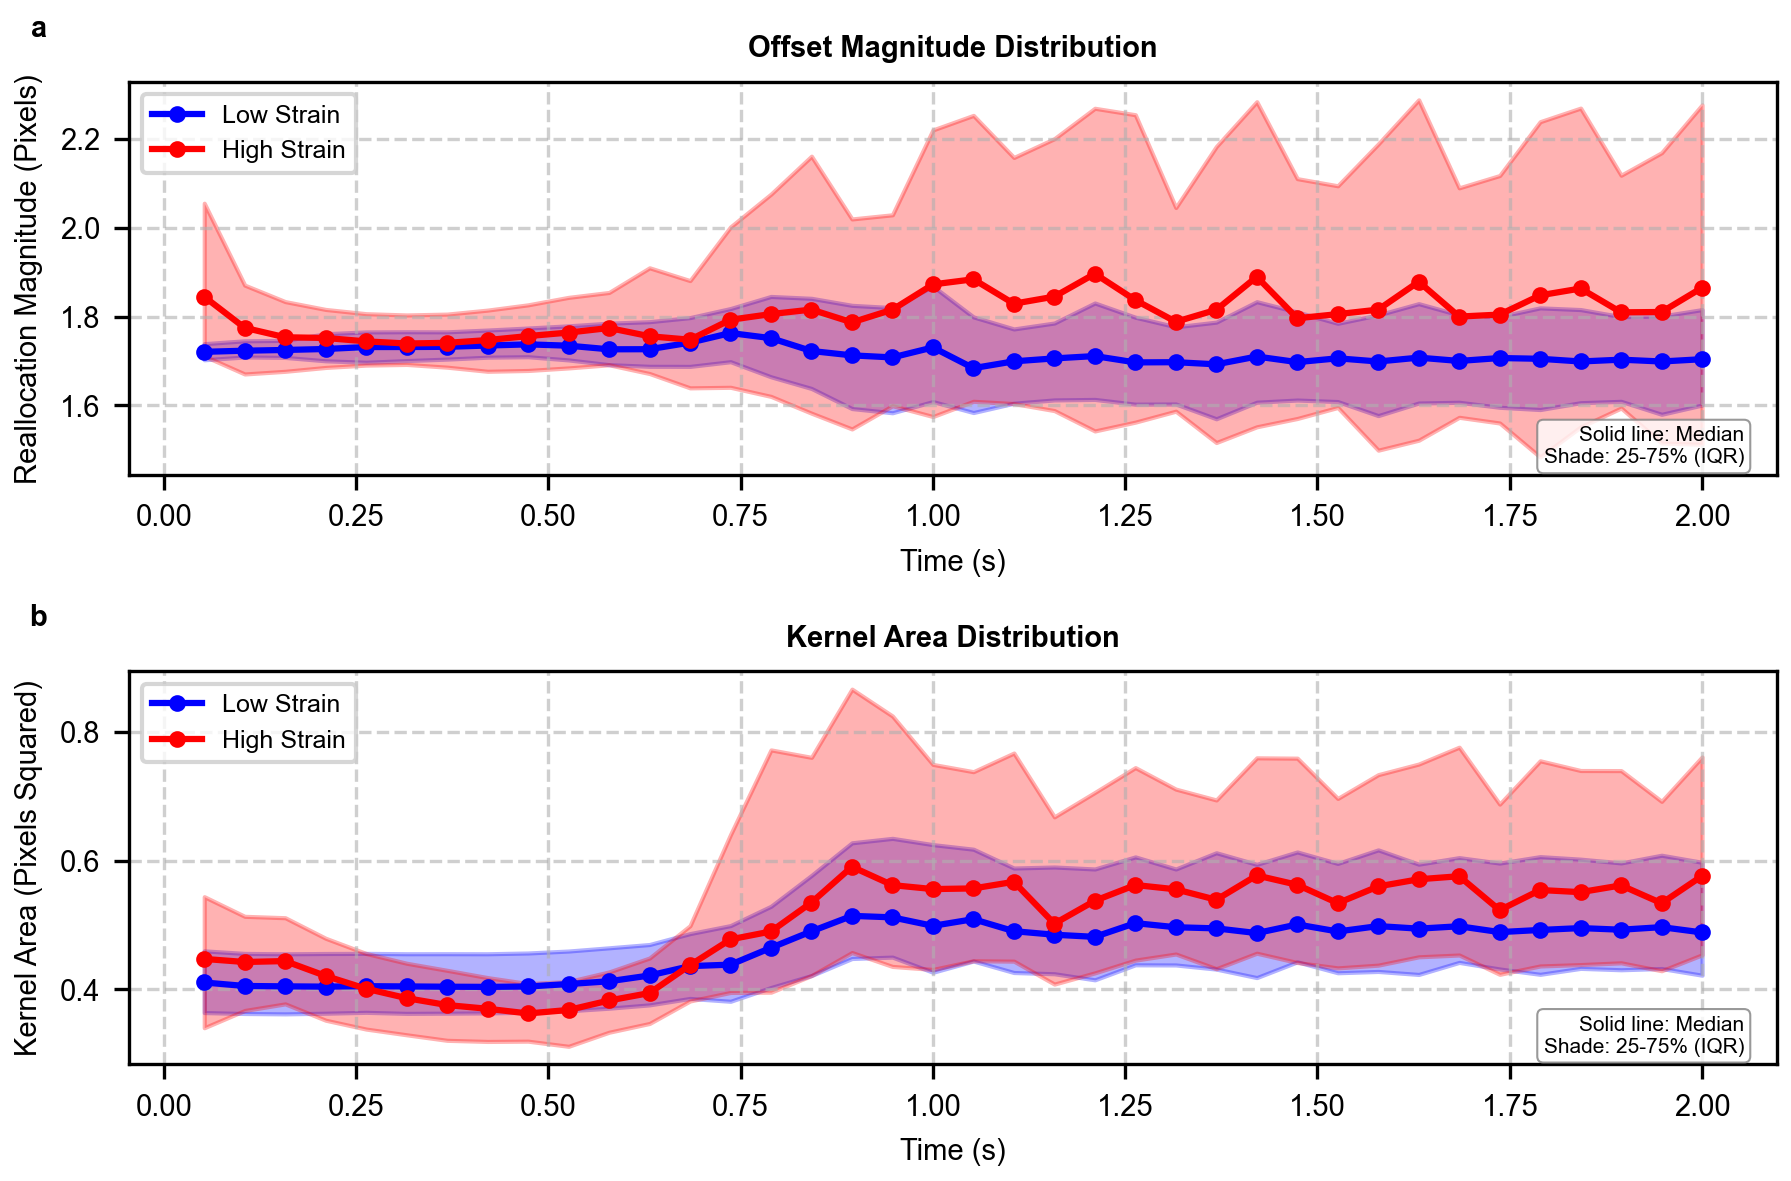

In [21]:
#!/usr/bin/env python3
"""
Figure A2: Panels A and B - Statistical Distributions for Navier-Stokes Data
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "ns_combined_vis_from_notebook"
SPLIT_METRIC = "strain"  # Only 'strain' available for NS data
SAMPLE_ID = 7

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell (Cell 1) first.")
if 'CSV_PATH' not in globals():
    raise NameError("Variable 'CSV_PATH' not found.")

def set_publication_style():
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, output_path):
    set_publication_style()
    
    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * 0.6
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.5)
    
    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    quantiles_to_plot = [25, 50, 75]

    # Panel A: Offset Magnitude
    ax_graph_a = fig.add_subplot(gs[0, 0])
    ax_graph_a.text(-0.05, 1.1, 'a', transform=ax_graph_a.transAxes, **label_props)
    ax_graph_a.set_title("Offset Magnitude Distribution", fontsize=7, weight='bold')
    ts_data_mag = sorted(stats_data_mag.keys())
    if ts_data_mag:
        # Convert timesteps to actual time: time = (timestep + 1) * 0.0526315789
        x = np.array([(t + 1) * 0.0526315789 for t in ts_data_mag])
        color_map_cats = {"low": "blue", "high": "red"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_mag[t] for t in ts_data_mag): continue
            quantiles = {f'q{q}': np.array([stats_data_mag[t].get(f"{cat_key}_q{q}", np.nan) 
                                           for t in ts_data_mag]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_a.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                          marker='o', markersize=3)
            ax_graph_a.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_a.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                   transform=ax_graph_a.transAxes, fontsize=5, verticalalignment='bottom', 
                   horizontalalignment='right', 
                   bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))
    ax_graph_a.set_xlabel("Time (s)")
    ax_graph_a.set_ylabel("Reallocation Magnitude (Pixels)")
    ax_graph_a.legend(loc='best', fontsize=6)
    ax_graph_a.grid(True, linestyle='--', alpha=0.6)

    # Panel B: Kernel Area
    ax_graph_b = fig.add_subplot(gs[1, 0])
    ax_graph_b.text(-0.05, 1.1, 'b', transform=ax_graph_b.transAxes, **label_props)
    ax_graph_b.set_title("Kernel Area Distribution", fontsize=7, weight='bold')
    ts_data_area = sorted(stats_data_area.keys())
    if ts_data_area:
        # Convert timesteps to actual time: time = (timestep + 1) * 0.0526315789
        x = np.array([(t + 1) * 0.0526315789 for t in ts_data_area])
        color_map_cats = {"low": "blue", "high": "red"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_area[t] for t in ts_data_area): continue
            quantiles = {f'q{q}': np.array([stats_data_area[t].get(f"{cat_key}_q{q}", np.nan) 
                                           for t in ts_data_area]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_b.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                          marker='o', markersize=3)
            ax_graph_b.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_b.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                   transform=ax_graph_b.transAxes, fontsize=5, verticalalignment='bottom', 
                   horizontalalignment='right', 
                   bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))
    ax_graph_b.set_xlabel("Time (s)")
    ax_graph_b.set_ylabel("Kernel Area (Pixels Squared)")
    ax_graph_b.legend(loc='best', fontsize=6)
    ax_graph_b.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
QUANTILES_TO_CALCULATE = [25, 50, 75]

# Calculate statistics on GLOBAL dataframe
all_timesteps_global = sorted(df['timestep'].unique())
stats_data_mag = {}
stats_data_area = {}
logging.info(f"Calculating statistics for Panels A & B using '{SPLIT_METRIC}' metric...")

if SPLIT_METRIC == 'strain':
    graph_labels = {"low": "Low Strain", "high": "High Strain"}
    for ts in all_timesteps_global:
        ts_df_global = df[df['timestep'] == ts]
        if ts_df_global.empty: continue
        stats_data_mag[ts] = {}
        stats_data_area[ts] = {}
        for cat_label, data_group in ts_df_global.groupby('strain_category'):
            data_mag = data_group['deformation_magnitude']
            stats_data_mag[ts][f"{cat_label}_q25"] = np.quantile(data_mag, 0.25) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q50"] = np.quantile(data_mag, 0.50) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q75"] = np.quantile(data_mag, 0.75) if not data_mag.empty else np.nan
            
            data_area = data_group['ellipse_area']
            stats_data_area[ts][f"{cat_label}_q25"] = np.quantile(data_area, 0.25) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q50"] = np.quantile(data_area, 0.50) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q75"] = np.quantile(data_area, 0.75) if not data_area.empty else np.nan

# Generate figure
layer_name = Path(CSV_PATH).stem.split('_per_pixel_analysis')[0]
out_file_pdf = Path(OUTPUT_DIR) / f"figA2_ab_{layer_name}_sample{SAMPLE_ID}_{SPLIT_METRIC}.pdf"
out_file_png = out_file_pdf.with_suffix('.png')

generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_pdf)
generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_png)

display(Markdown(f"### Figure A2 (A-B) saved to: `{out_file_pdf.resolve()}`"))
display(Image(filename=out_file_png))

In [4]:
################################################################################
# CELL 1: Load Burgers Data and Perform Global Clustering (Run this cell only once)
################################################################################

#!/usr/bin/env python3
"""
CELL 1: Data Loading and Global Processing for Burgers Equation Data

This cell loads the unified CSV data file for the Burgers dataset and performs
global K-Means clustering. It should be run once to make the processed data
available for the visualization cell that follows.
"""

import pandas as pd
from pathlib import Path
import logging
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
import numpy as np

# ------------------------------------------------------------------- #
# Configuration - EDIT THIS VALUE
# ------------------------------------------------------------------- #
# Path to the unified data CSV file for the Burgers dataset.
CSV_PATH = '/home/jtb3sud/PARCtorch/PARCtorch/scripts/ns_scripts/burgers_subset_15M.csv'

# --- Setup ---
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

# --- Load and Process Data from CSV ---
display(Markdown(f"### Loading data from `{CSV_PATH}`..."))
try:
    df = pd.read_csv(CSV_PATH)
    display(Markdown(f"**Successfully loaded data with {len(df)} rows.**"))
    
    # --- Perform global K-Means clustering on the ENTIRE dataframe ---
    if 'strain_rate_magnitude' in df.columns:
        logging.info("Performing global K-Means clustering on the entire CSV's strain data...")
        strain_values = df[['strain_rate_magnitude']].values
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(strain_values)
        centers = kmeans.cluster_centers_.flatten()
        label_map = {np.argmin(centers): "low", np.argmax(centers): "high"}
        df['strain_category'] = kmeans.predict(strain_values)
        df['strain_category'] = df['strain_category'].map(label_map)
        logging.info("Global clustering complete. 'strain_category' column added.")
    
    display(df.head())
    
    available_samples = sorted(df['sample_id'].unique())
    display(Markdown(f"**Available `sample_id` values:** `{available_samples}`"))
    
except FileNotFoundError:
    logging.error(f"Error: CSV file not found at {CSV_PATH}")
    df = None

### Loading data from `/home/jtb3sud/PARCtorch/PARCtorch/scripts/ns_scripts/burgers_subset_15M.csv`...

**Successfully loaded data with 14745600 rows.**

2025-10-11 15:21:40,623 [INFO] Performing global K-Means clustering on the entire CSV's strain data...
2025-10-11 15:22:12,271 [INFO] Global clustering complete. 'strain_category' column added.


,anisotropy,orientation,ellipse_area,shear_magnitude,deformation_magnitude,centroid_skew_magnitude,sample_id,timestep,pixel_y,pixel_x,...,offset_k4_dx,offset_k5_dy,offset_k5_dx,offset_k6_dy,offset_k6_dx,offset_k7_dy,offset_k7_dx,offset_k8_dy,offset_k8_dx,strain_category
0,2.91893,93.2321,3.20356,0.027563,0.846974,0.171172,2,0,0,0,...,0.004627,0.234557,0.794042,-0.937169,-0.638144,0.066726,-0.368302,-1.24891,-0.274999,low
1,4.98707,106.6920,2.54753,0.183218,1.008090,0.570486,2,0,0,1,...,0.084953,-0.911688,1.790530,-0.700233,-0.087172,-0.817102,0.697040,-1.96402,-0.539416,low
2,4.90178,106.3090,2.60146,0.178185,1.021120,0.589244,2,0,0,2,...,0.093218,-0.905112,1.810270,-0.715899,-0.093835,-0.838512,0.723538,-2.01044,-0.518795,low
3,4.82892,106.1060,2.66636,0.175080,1.039250,0.611212,2,0,0,3,...,0.099164,-0.911898,1.843190,-0.726805,-0.092831,-0.867249,0.761041,-2.05739,-0.505409,low
4,4.83109,106.0940,2.70794,0.174990,1.057160,0.625711,2,0,0,4,...,0.101339,-0.926794,1.873140,-0.732736,-0.091998,-0.886533,0.787095,-2.09817,-0.503803,low


**Available `sample_id` values:** `[2, 8, 18, 22, 32, 41, 43, 47, 71, 73, 76, 78, 86, 98, 100, 103, 150, 157, 183, 194, 200, 203, 215, 236, 252, 266, 283, 290, 291, 295, 305, 307, 317, 319, 322, 369]`

/tmp/ipykernel_310695/243471077.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_310695/243471077.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure A1 (A-D) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/hmx_scripts/burgers_combined_vis_from_notebook/figA1_abcd_burgers_sample2_strain_rate_magnitude.pdf`

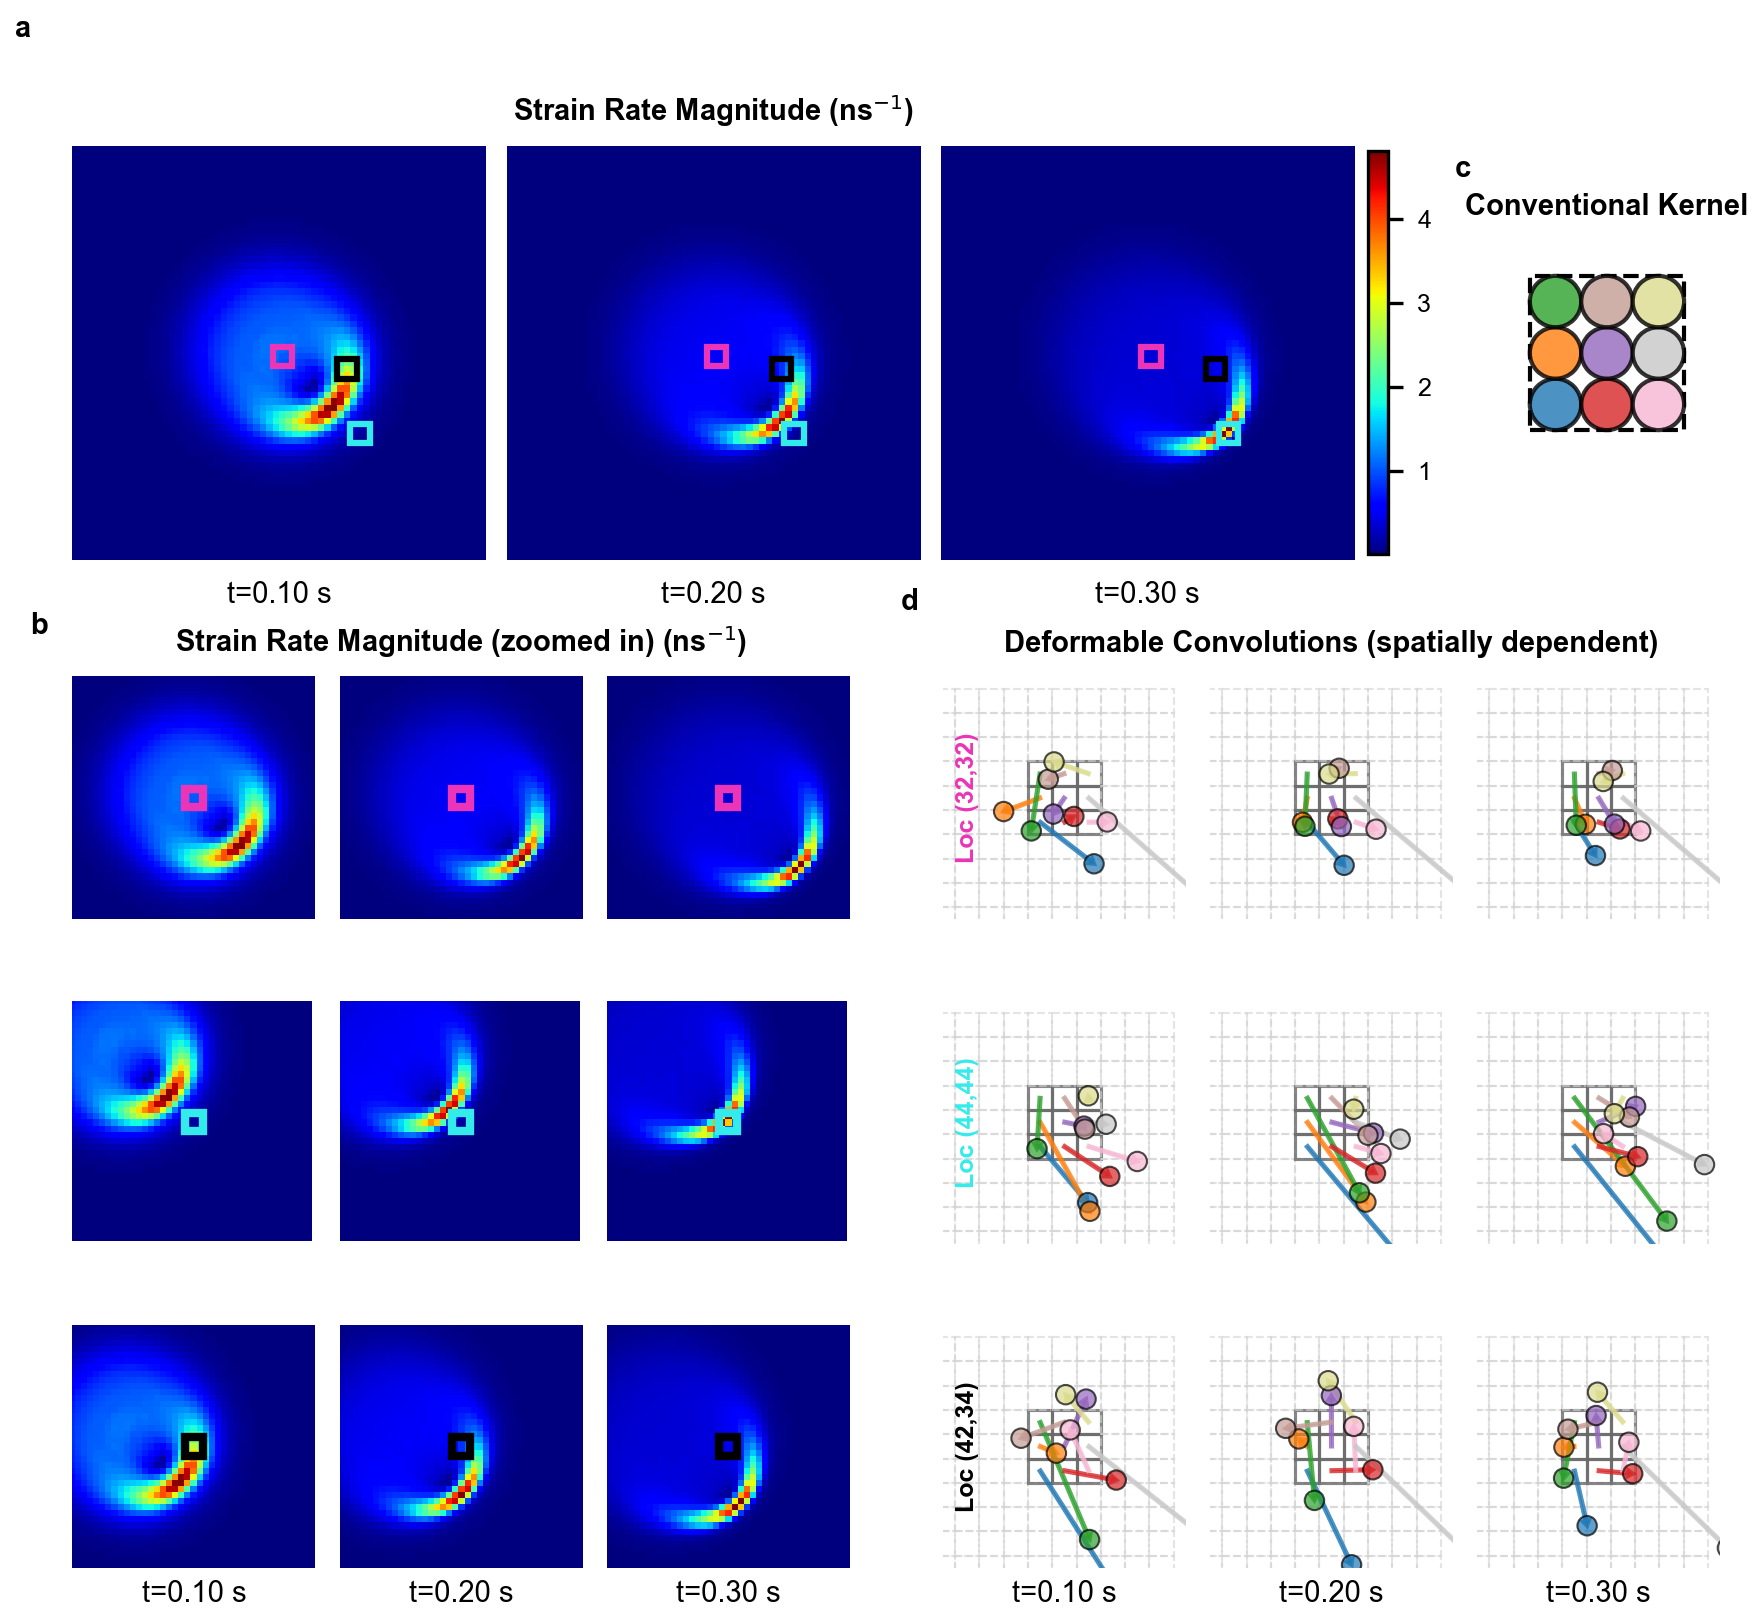

In [17]:
#!/usr/bin/env python3
"""
Figure A1: Panels A, B, C, D - Spatial Visualization for Burgers Equation Data
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Circle
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "burgers_combined_vis_from_notebook"
VISUALIZATION_METRIC = 'strain_rate_magnitude'
SPATIAL_LOCATIONS = [32, 32, 44, 44, 42, 34]
TIMESTEPS = [5, 10, 15]
SAMPLE_ID = 2

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell first.")
if 'CSV_PATH' not in globals():
    raise NameError("Variable 'CSV_PATH' not found. Please define it with the path to your data file.")

# Static variables
color_map = plt.get_cmap("tab20")
kernel_colors = [color_map(i) for i in np.linspace(0, 1, 9, endpoint=False)]
grid_coords = np.array([[-1,-1],[-1,0],[-1,1],[0,-1],[0,0],[0,1],[1,-1],[1,0],[1,1]], dtype=np.float32)
zoom_limits = {"initial_doubleConv": 4, "upBlock_3": 4}

def set_publication_style():
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_abcd_figure(spatial_locations, display_channels_by_ts, offset_fields_by_ts,
                         layer_key, output_path, title_prefix):
    set_publication_style()
    num_locations = len(spatial_locations)
    timesteps_to_plot = sorted(display_channels_by_ts.keys())
    num_ts = len(timesteps_to_plot)

    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * (0.28 * num_locations + 0.5)
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    
    gs_main = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, num_locations * 0.35], hspace=-0.46)
    a_c_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0],
                                              width_ratios=[num_ts, 0.5], wspace=0.08)
    a_gs = gridspec.GridSpecFromSubplotSpec(1, num_ts, subplot_spec=a_c_gs[0, 0], wspace=0.05)
    b_d_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1],
                                              width_ratios=[1, 1], wspace=0.12)
    
    b_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 0],
                                            wspace=0.1, hspace=-0.6)
    d_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 1],
                                            wspace=0.1, hspace=-0.6)

    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    cmap = "jet"
    rec_colors = ['#eb34b7', '#34ebeb', '#000000', '#34eb3d']
    H_offset, W_offset = next(iter(display_channels_by_ts.values())).shape

    # Panel A - Single title on middle subplot
    panel_a_axes = []
    panel_a_ims = []  # Store image objects for colorbar
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        ax_full_view = fig.add_subplot(a_gs[0, i])
        panel_a_axes.append(ax_full_view)
        im = ax_full_view.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        panel_a_ims.append(im)
        
        # Only show title on the middle subplot
        if i == 1:
            ax_full_view.set_title(f"{title_prefix} (ns$^{{-1}}$)", fontsize=7, weight='bold')
        
        # Add time label at bottom - convert timestep to actual time
        # Formula: time = timestep * 0.02
        time_value = ts * 0.02
        ax_full_view.text(0.5, -0.05, f"t={time_value:.2f} s", transform=ax_full_view.transAxes,
                         ha='center', va='top', fontsize=7)
        
        ax_full_view.axis('off')
        if i == 0: 
            ax_full_view.text(-0.1, 1.25, 'a', transform=ax_full_view.transAxes, **label_props)
        for loc_idx, (cur_x, cur_y) in enumerate(spatial_locations):
            ax_full_view.add_patch(Rectangle((cur_x - 1.5, cur_y - 1.5), 3, 3, lw=1.5,
                                             ec=rec_colors[loc_idx % len(rec_colors)], fc='none'))
    
    # Add colorbar for Panel A (matching EM formatting)
    cbar_a = fig.colorbar(panel_a_ims[-1], ax=panel_a_axes, fraction=0.046, pad=0.01, shrink=0.29)
    cbar_a.ax.tick_params(labelsize=6)

    # Panel B - Single title with "zoomed in" on middle subplot of top row
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        for zoom_idx, (zoom_loc_x, zoom_loc_y) in enumerate(spatial_locations):
            ax_zoom = fig.add_subplot(b_gs[zoom_idx, i])
            if zoom_idx == 0 and i == 1:
                ax_zoom.set_title(f"{title_prefix} (zoomed in) (ns$^{{-1}}$)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if zoom_idx == num_locations - 1:
                # Convert timestep to actual time: time = timestep * 0.02
                time_value = ts * 0.02
                ax_zoom.text(0.5, -0.05, f"t={time_value:.2f} s", transform=ax_zoom.transAxes,
                           ha='center', va='top', fontsize=7)
            
            ax_zoom.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
            ax_zoom.set_xlim(zoom_loc_x - 20, zoom_loc_x + 20)
            ax_zoom.set_ylim(zoom_loc_y + 20, zoom_loc_y - 20)
            ax_zoom.set_aspect('equal', adjustable='box')
            ax_zoom.add_patch(Rectangle((zoom_loc_x - 1.5, zoom_loc_y - 1.5), 3, 3, lw=2,
                                        ec=rec_colors[zoom_idx % len(rec_colors)], fc='none'))
            ax_zoom.axis('off')
            if i == 0 and zoom_idx == 0:
                ax_zoom.text(-0.1, 1.15, 'b', transform=ax_zoom.transAxes, **label_props)

    # Panel C
    ax_conv_kernel = fig.add_subplot(a_c_gs[0, 1])
    ax_conv_kernel.set_title("Conventional Kernel", fontsize=7, weight='bold')
    ax_conv_kernel.set_aspect('equal', adjustable='box')
    ax_conv_kernel.set_xlim(-2.2, 2.2)
    ax_conv_kernel.set_ylim(-2.2, 2.2)
    ax_conv_kernel.axis("off")
    ax_conv_kernel.text(-0.1, 1.25, 'c', transform=ax_conv_kernel.transAxes, **label_props)
    ax_conv_kernel.add_patch(Rectangle((-1.5, -1.5), 3, 3, lw=1, ec='k', fc='none', linestyle='--'))
    for i_el in range(9):
        ax_conv_kernel.add_patch(Circle((grid_coords[i_el][0], grid_coords[i_el][1]),
                                        radius=0.5, lw=1, ec='k', fc=kernel_colors[i_el], alpha=0.8))

    # Panel D - Single title with "spatially dependent" on middle subplot of top row
    for i_loc, (cur_x, cur_y) in enumerate(spatial_locations):
        for j_ts, ts in enumerate(timesteps_to_plot):
            ax_def = fig.add_subplot(d_gs[i_loc, j_ts])
            if i_loc == 0 and j_ts == 1:
                ax_def.set_title("Deformable Convolutions (spatially dependent)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if i_loc == num_locations - 1:
                # Convert timestep to actual time: time = timestep * 0.02
                time_value = ts * 0.02
                ax_def.text(0.5, -0.05, f"t={time_value:.2f} s", transform=ax_def.transAxes,
                          ha='center', va='top', fontsize=7)
            
            if i_loc == 0 and j_ts == 0:
                ax_def.text(-0.1, 1.25, 'd', transform=ax_def.transAxes, **label_props)
            zoom_lim = zoom_limits.get(layer_key, 5)
            if j_ts == 0:
                ax_def.text(-zoom_lim * 0.8, 0, f"Loc ({cur_x},{cur_y})", rotation=90, size=6,
                            ha='center', va='center',
                            color=rec_colors[i_loc % len(rec_colors)], fontweight='bold')
            ax_def.set_aspect('equal', adjustable='box')
            ax_def.set_xlim(-zoom_lim, zoom_lim)
            ax_def.set_ylim(-zoom_lim, zoom_lim)
            ax_def.axis("off")
            grid_range = int(np.ceil(zoom_lim))
            for x_g in range(-grid_range, grid_range):
                for y_g in range(-grid_range, grid_range):
                    is_central = -1 <= x_g < 2 and -1 <= y_g < 2
                    ax_def.add_patch(Rectangle((x_g - 0.5, y_g - 0.5), 1, 1,
                                               lw=0.75 if is_central else 0.5,
                                               ec='dimgray' if is_central else 'lightgray',
                                               fc='none', ls='-' if is_central else '--',
                                               alpha=0.8 if is_central else 0.6))
            offsets_at_loc = offset_fields_by_ts.get(ts, {}).get((cur_y, cur_x), np.zeros((9, 2)))
            for i_el in range(9):
                offset_yx = offsets_at_loc[i_el]
                # Negate y-component since image coordinates (y down) differ from plot coordinates (y up)
                offset_vec = np.array([offset_yx[1], -offset_yx[0]])
                start_point = grid_coords[i_el]
                endpoint = start_point + offset_vec
                
                # Draw colored vector for the offset
                if np.linalg.norm(offset_vec) > 0.01:
                    ax_def.arrow(start_point[0], start_point[1],
                                 offset_vec[0], offset_vec[1],
                                 head_width=0.25, head_length=0.2,
                                 width=0.04, fc=kernel_colors[i_el],
                                 ec=kernel_colors[i_el], alpha=0.8,
                                 length_includes_head=True)
                
                ax_def.add_patch(Circle((endpoint[0], endpoint[1]), radius=0.4,
                                        lw=0.5, ec='k', fc=kernel_colors[i_el], alpha=0.7, zorder=10))

    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
spatial_locs = list(zip(SPATIAL_LOCATIONS[::2], SPATIAL_LOCATIONS[1::2]))

sample_df = df[df['sample_id'] == SAMPLE_ID].copy()
if sample_df.empty:
    logging.error(f"No data found for sample_id {SAMPLE_ID}.")
else:
    offsets_by_ts, preds_by_ts = {}, {}
    for ts in TIMESTEPS:
        ts_df = sample_df[sample_df['timestep'] == ts]
        if ts_df.empty: continue
        preds_by_ts[ts] = ts_df.pivot_table(index='pixel_y', columns='pixel_x', values=VISUALIZATION_METRIC).values
        offset_cols = [f'offset_k{i}_d{ax}' for i in range(9) for ax in ['y', 'x']]
        loc_df = ts_df.set_index(['pixel_y', 'pixel_x'])
        offsets_by_ts[ts] = {}
        for x, y in spatial_locs:
            if (y, x) in loc_df.index:
                offsets_flat = loc_df.loc[(y, x), offset_cols].values
                offsets_by_ts[ts][(y, x)] = np.stack([offsets_flat[::2], offsets_flat[1::2]], axis=-1)

    if preds_by_ts:
        layer_name = Path(CSV_PATH).stem.split('_subset_')[0] if '_subset_' in Path(CSV_PATH).stem else Path(CSV_PATH).stem.split('_per_pixel_analysis')[0]
        clean_metric_name = VISUALIZATION_METRIC.replace(" ", "_").replace("(", "").replace(")", "")
        out_file_pdf = Path(OUTPUT_DIR) / f"figA1_abcd_{layer_name}_sample{SAMPLE_ID}_{clean_metric_name}.pdf"
        out_file_png = out_file_pdf.with_suffix('.png')
        
        # Use "Strain Rate" as the title instead of "Strain Rate Magnitude"
        title_prefix = "Strain Rate Magnitude"

        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_pdf, title_prefix)
        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_png, title_prefix)

        display(Markdown(f"### Figure A1 (A-D) saved to: `{out_file_pdf.resolve()}`"))
        display(Image(filename=out_file_png))

2025-10-11 15:33:58,337 [INFO] Calculating statistics for Panels A & B using 'strain' metric...
/tmp/ipykernel_310695/2972188588.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_310695/2972188588.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure A2 (A-B) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/hmx_scripts/burgers_combined_vis_from_notebook/figA2_ab_burgers_sample2_strain.pdf`

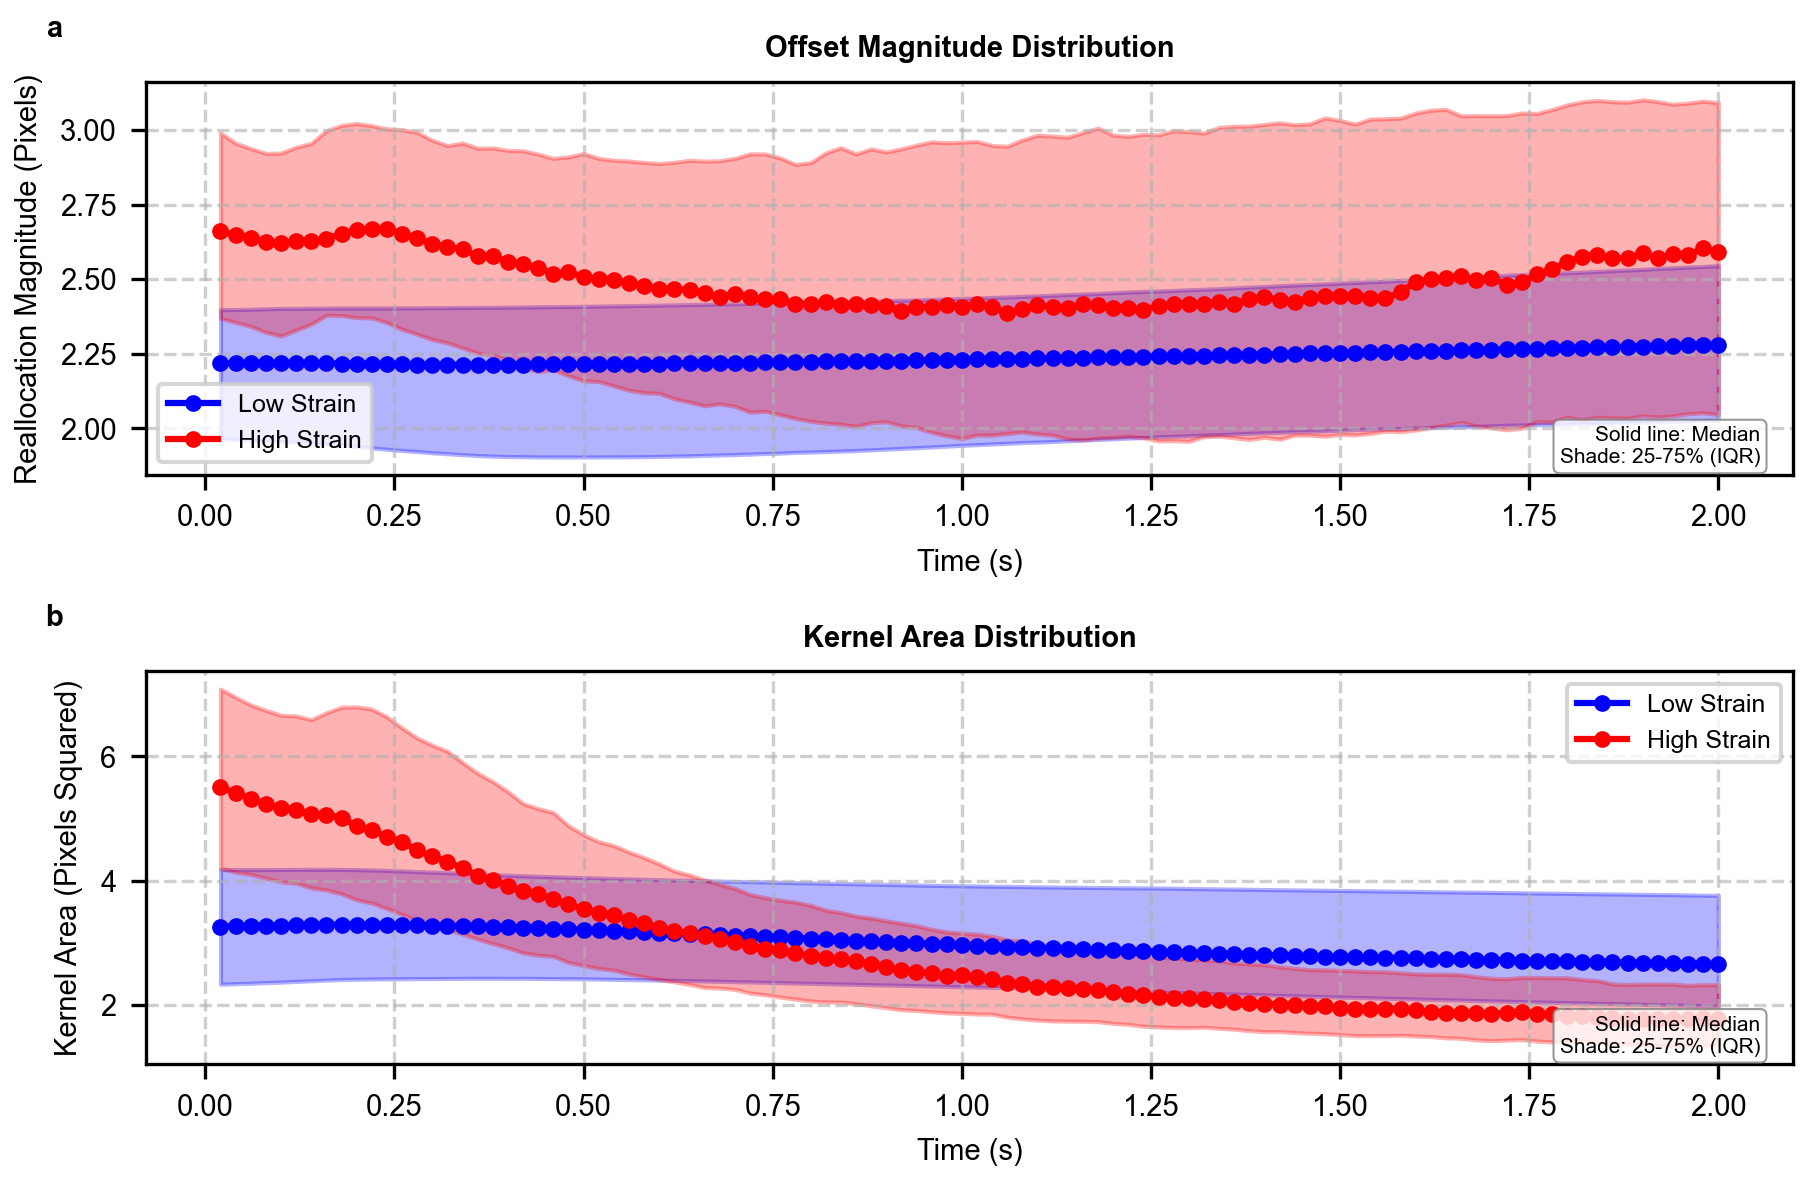

In [15]:
#!/usr/bin/env python3
"""
Figure A2: Panels A and B - Statistical Distributions for Burgers Equation Data
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "burgers_combined_vis_from_notebook"
SPLIT_METRIC = "strain"  # Only 'strain' available for Burgers data
SAMPLE_ID = 2

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell (Cell 1) first.")
if 'CSV_PATH' not in globals():
    raise NameError("Variable 'CSV_PATH' not found.")

def set_publication_style():
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, output_path):
    set_publication_style()
    
    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * 0.6
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.5)
    
    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    quantiles_to_plot = [25, 50, 75]

    # Panel A: Offset Magnitude
    ax_graph_a = fig.add_subplot(gs[0, 0])
    ax_graph_a.text(-0.05, 1.1, 'a', transform=ax_graph_a.transAxes, **label_props)
    ax_graph_a.set_title("Offset Magnitude Distribution", fontsize=7, weight='bold')
    ts_data_mag = sorted(stats_data_mag.keys())
    if ts_data_mag:
        # Convert timesteps to actual time: time = (timestep + 1) * 0.02
        x = np.array([(t + 1) * 0.02 for t in ts_data_mag])
        color_map_cats = {"low": "blue", "high": "red"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_mag[t] for t in ts_data_mag): continue
            quantiles = {f'q{q}': np.array([stats_data_mag[t].get(f"{cat_key}_q{q}", np.nan) 
                                           for t in ts_data_mag]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_a.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                          marker='o', markersize=3)
            ax_graph_a.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_a.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                   transform=ax_graph_a.transAxes, fontsize=5, verticalalignment='bottom', 
                   horizontalalignment='right', 
                   bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))
    ax_graph_a.set_xlabel("Time (s)")
    ax_graph_a.set_ylabel("Reallocation Magnitude (Pixels)")
    ax_graph_a.legend(loc='best', fontsize=6)
    ax_graph_a.grid(True, linestyle='--', alpha=0.6)

    # Panel B: Kernel Area
    ax_graph_b = fig.add_subplot(gs[1, 0])
    ax_graph_b.text(-0.05, 1.1, 'b', transform=ax_graph_b.transAxes, **label_props)
    ax_graph_b.set_title("Kernel Area Distribution", fontsize=7, weight='bold')
    ts_data_area = sorted(stats_data_area.keys())
    if ts_data_area:
        # Convert timesteps to actual time: time = (timestep + 1) * 0.02
        x = np.array([(t + 1) * 0.02 for t in ts_data_area])
        color_map_cats = {"low": "blue", "high": "red"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_area[t] for t in ts_data_area): continue
            quantiles = {f'q{q}': np.array([stats_data_area[t].get(f"{cat_key}_q{q}", np.nan) 
                                           for t in ts_data_area]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_b.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                          marker='o', markersize=3)
            ax_graph_b.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_b.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                   transform=ax_graph_b.transAxes, fontsize=5, verticalalignment='bottom', 
                   horizontalalignment='right', 
                   bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))
    ax_graph_b.set_xlabel("Time (s)")
    ax_graph_b.set_ylabel("Kernel Area (Pixels Squared)")
    ax_graph_b.legend(loc='best', fontsize=6)
    ax_graph_b.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
QUANTILES_TO_CALCULATE = [25, 50, 75]

# Calculate statistics on GLOBAL dataframe
all_timesteps_global = sorted(df['timestep'].unique())
stats_data_mag = {}
stats_data_area = {}
logging.info(f"Calculating statistics for Panels A & B using '{SPLIT_METRIC}' metric...")

if SPLIT_METRIC == 'strain':
    graph_labels = {"low": "Low Strain", "high": "High Strain"}
    for ts in all_timesteps_global:
        ts_df_global = df[df['timestep'] == ts]
        if ts_df_global.empty: continue
        stats_data_mag[ts] = {}
        stats_data_area[ts] = {}
        for cat_label, data_group in ts_df_global.groupby('strain_category'):
            data_mag = data_group['deformation_magnitude']
            stats_data_mag[ts][f"{cat_label}_q25"] = np.quantile(data_mag, 0.25) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q50"] = np.quantile(data_mag, 0.50) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q75"] = np.quantile(data_mag, 0.75) if not data_mag.empty else np.nan
            
            data_area = data_group['ellipse_area']
            stats_data_area[ts][f"{cat_label}_q25"] = np.quantile(data_area, 0.25) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q50"] = np.quantile(data_area, 0.50) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q75"] = np.quantile(data_area, 0.75) if not data_area.empty else np.nan

# Generate figure
layer_name = Path(CSV_PATH).stem.split('_subset_')[0] if '_subset_' in Path(CSV_PATH).stem else Path(CSV_PATH).stem.split('_per_pixel_analysis')[0]
out_file_pdf = Path(OUTPUT_DIR) / f"figA2_ab_{layer_name}_sample{SAMPLE_ID}_{SPLIT_METRIC}.pdf"
out_file_png = out_file_pdf.with_suffix('.png')

generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_pdf)
generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_png)

display(Markdown(f"### Figure A2 (A-B) saved to: `{out_file_pdf.resolve()}`"))
display(Image(filename=out_file_png))

/tmp/ipykernel_235694/3582176896.py:357: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0, rect=[0.01, 0, 1, 1])


✅ Figure saved successfully to: /sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/hmx_scripts/deformable_kernel_visualization.pdf


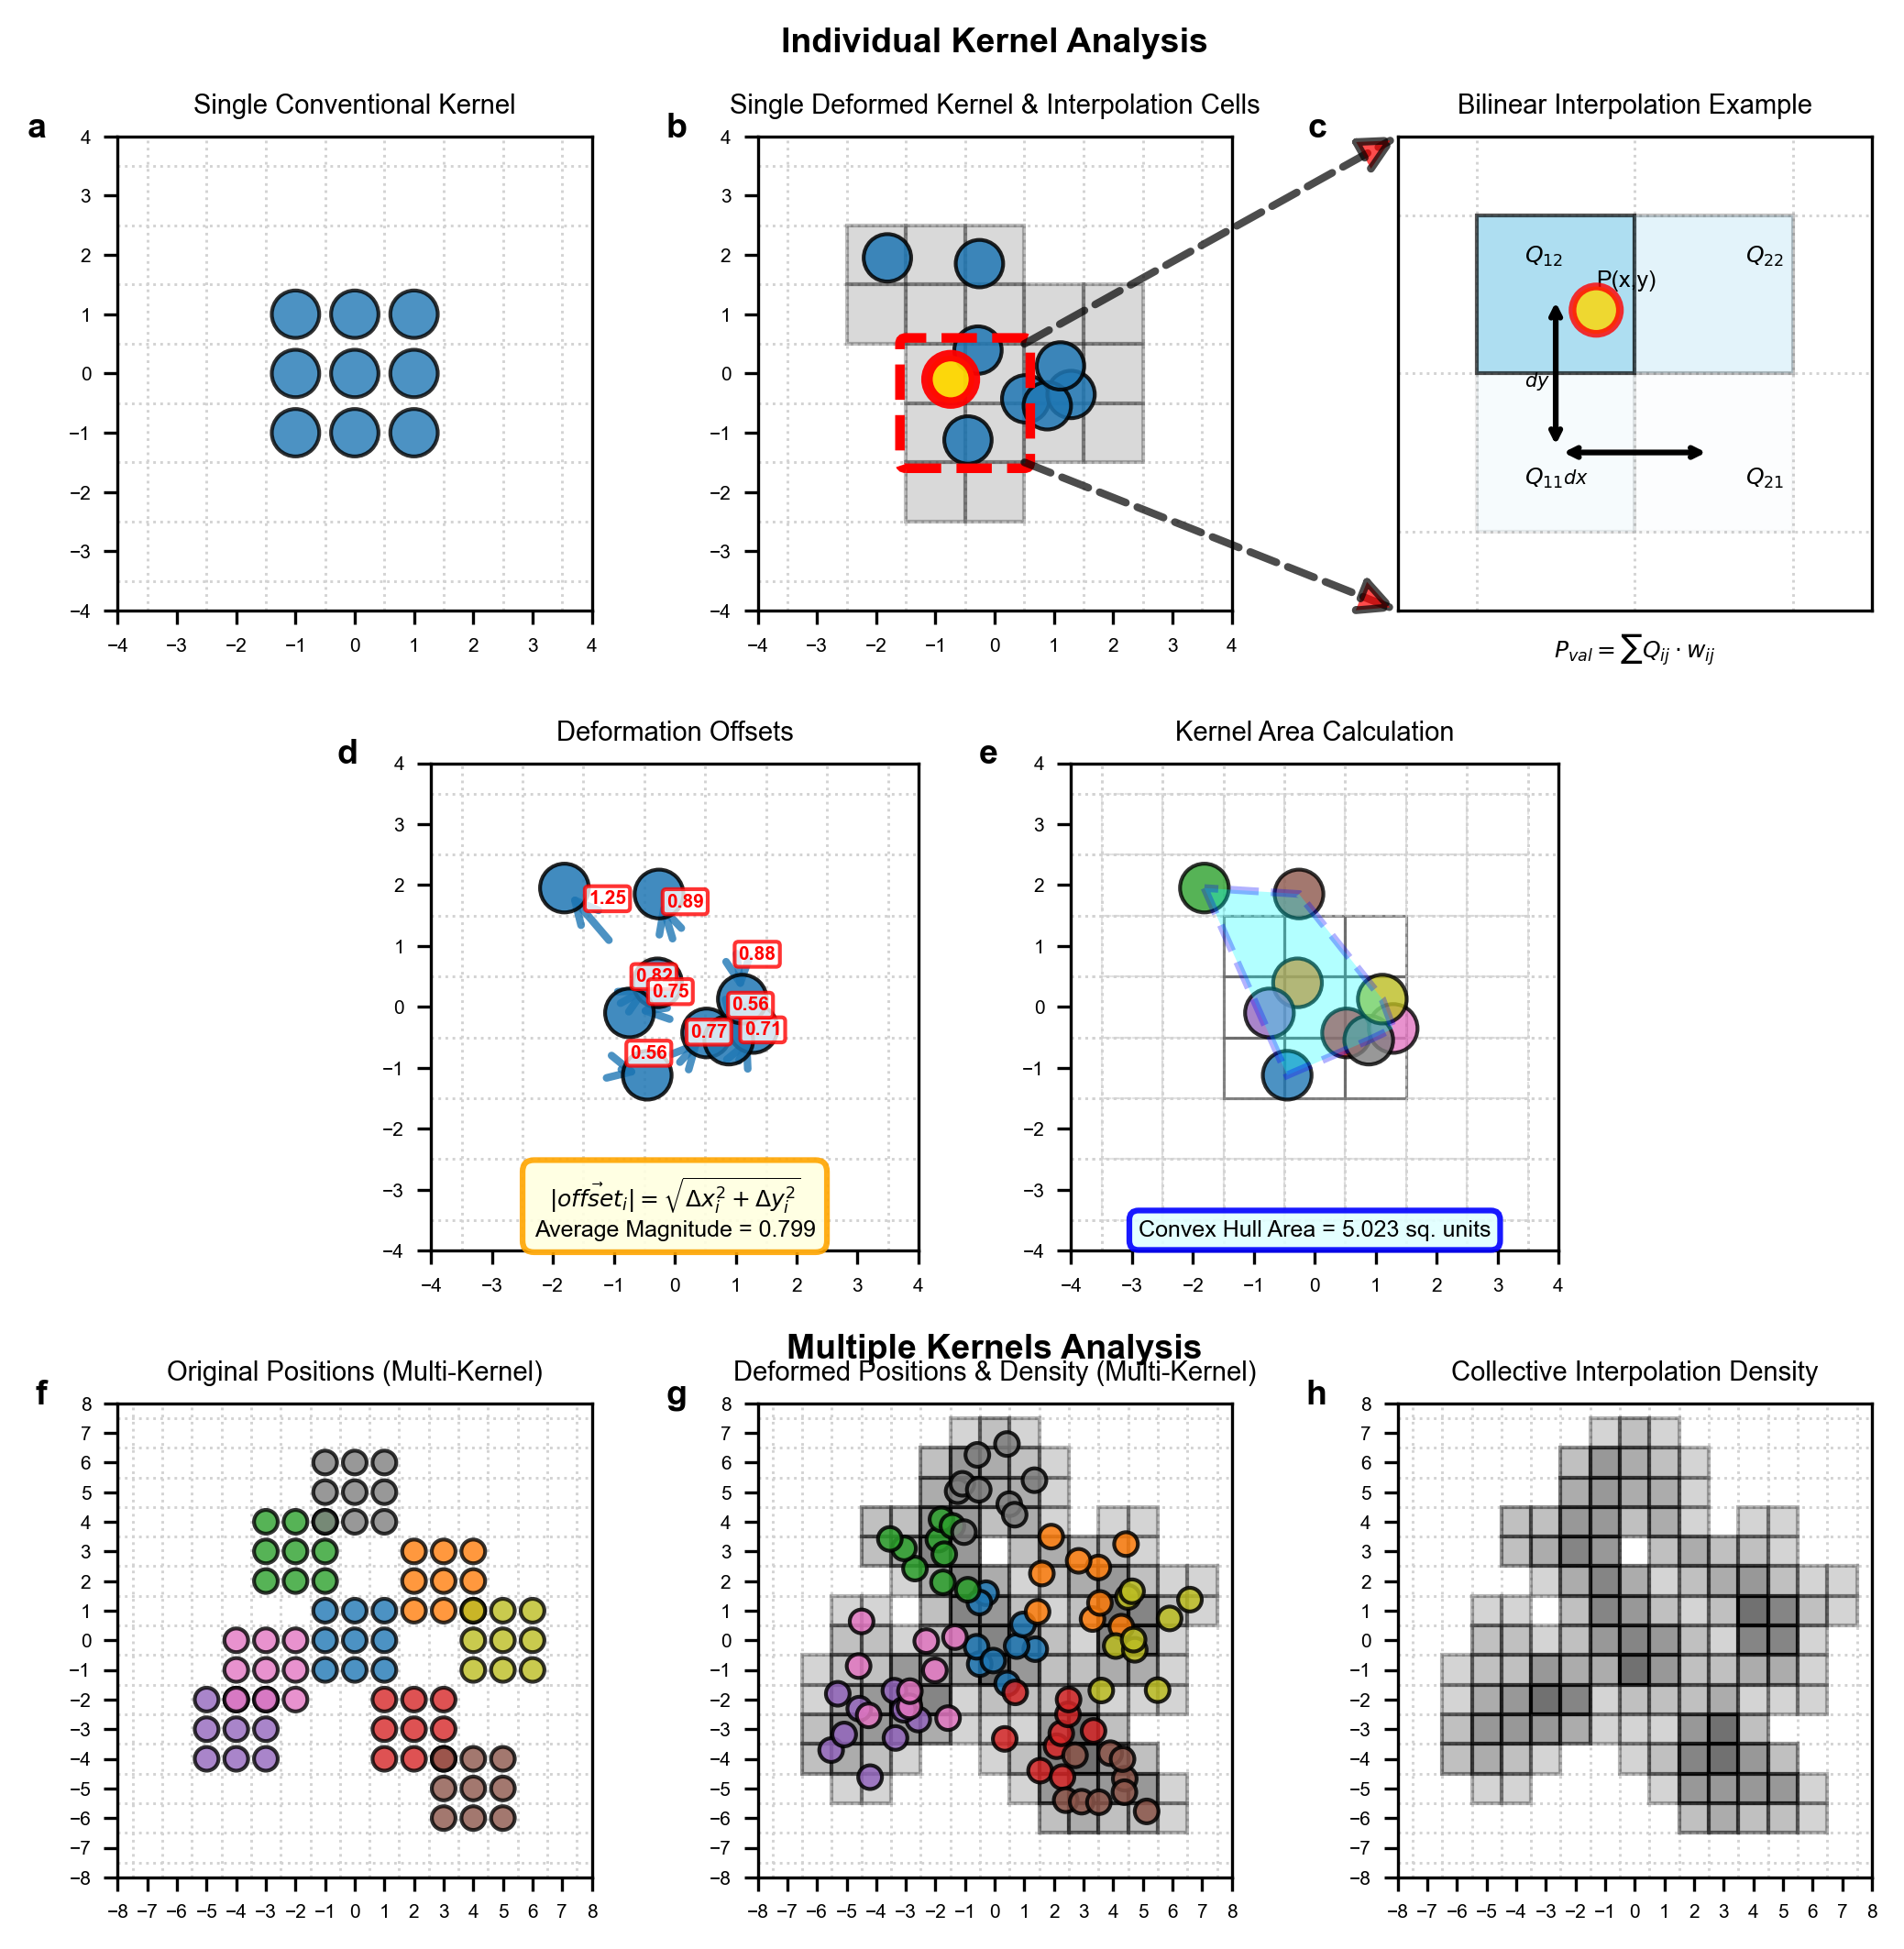

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, ConnectionPatch, FancyArrowPatch, Polygon
from collections import Counter
from pathlib import Path
from scipy.spatial import ConvexHull

# --- Globals ---
# Colors for the multi-kernel plots (one color per kernel)
kernel_base_colors = plt.get_cmap("tab10").colors
# A single color for the kernel in the top plots
single_kernel_color = kernel_base_colors[0] 
# The standard 3x3 grid centered at (0,0)
grid_coords = np.array([[-1, -1], [-1, 0], [-1, 1],
                        [0, -1], [0, 0], [0, 1],
                        [1, -1], [1, 0], [1, 1]], dtype=np.float32)

rng = np.random.default_rng(42)

# --- 2D Drawing Functions ---
def draw_circle_2d(ax, x, y, diameter=1, facecolor='blue', alpha=0.8, **kwargs):
    """Draws a 2D circle centered at (x, y)."""
    circle = patches.Circle((x, y), diameter / 2,
                              facecolor=facecolor, alpha=alpha, **kwargs)
    ax.add_patch(circle)
    
def draw_grid_square(ax, x, y, size=1, facecolor='gray', alpha=0.2, **kwargs):
    """Draws a 2D grid square, defined by its center."""
    rect = patches.Rectangle((x - size / 2, y - size / 2), size, size,
                              facecolor=facecolor, alpha=alpha, **kwargs)
    ax.add_patch(rect)

# --- Configuration ---
kernel_anchors = [
    np.array([0, 0]), np.array([3, 2]), np.array([-2, 3]),
    np.array([2, -3]), np.array([-4, -3]), np.array([4, -5]),
    np.array([-3, -1]), np.array([0, 5]), np.array([5, 0])
]
spread_scale = 1.5
element_diameter = 0.8
output_filename = "deformable_kernel_visualization.pdf"

# Set publication-quality parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 6,
    'axes.labelsize': 6,
    'axes.titlesize': 7,
    'xtick.labelsize': 5,
    'ytick.labelsize': 5,
    'legend.fontsize': 5,
    'figure.dpi': 300
})

# Create figure with 180mm width (7.087 inches)
fig_width_mm = 180
fig_width_inch = fig_width_mm / 25.4  # Convert mm to inches
fig_height_inch = fig_width_inch * 1.0  # Maintain aspect ratio

fig = plt.figure(figsize=(fig_width_inch, fig_height_inch), dpi=300)
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.35, top=0.95, bottom=0.05, left=0.05, right=0.95)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])
ax_d = fig.add_subplot(gs[1, 0:2])  # Spans first two columns
ax_e = fig.add_subplot(gs[1, 1:3])  # Spans last two columns (overlaps with D for centering)
ax_f = fig.add_subplot(gs[2, 0])
ax_g = fig.add_subplot(gs[2, 1])
ax_h = fig.add_subplot(gs[2, 2])

# Add section label for individual kernel
fig.text(0.5, 0.99, 'Individual Kernel Analysis', ha='center', fontsize=9, fontweight='bold')

# --- TOP ROW: SINGLE KERNEL & INTERPOLATION ---

# Top-Left (A): Single Conventional Kernel
ax_a.set_title("Single Conventional Kernel", fontsize=7)
for i, (gx, gy) in enumerate(grid_coords):
    draw_circle_2d(ax_a, gx, gy, diameter=element_diameter, facecolor=single_kernel_color, alpha=0.8, edgecolor='k')

# Top-Middle (B): Single Deformed Kernel
ax_b.set_title("Single Deformed Kernel & Interpolation Cells", fontsize=7)
single_kernel_spread = 2.0
single_kernel_offsets = rng.uniform(-0.5, 0.5, size=(9, 2)) * single_kernel_spread
single_deformed_points = grid_coords + single_kernel_offsets

single_kernel_interp_counter = Counter()
for point in single_deformed_points:
    px_temp, py_temp = point
    neighbors = [(np.floor(px_temp), np.floor(py_temp)), (np.ceil(px_temp), np.floor(py_temp)),
                 (np.floor(px_temp), np.ceil(py_temp)), (np.ceil(px_temp), np.ceil(py_temp))]
    single_kernel_interp_counter.update(map(tuple, neighbors))

base_density_color = 'dimgray'
for (nx, ny) in single_kernel_interp_counter.keys():
    draw_grid_square(ax_b, nx, ny, facecolor=base_density_color, alpha=0.25, edgecolor=(0, 0, 0, 0.3))

# Draw all particles, but highlight the selected one (index 4, the center)
selected_idx = 4
particle_pos = single_deformed_points[selected_idx]
px, py = particle_pos

for i, point in enumerate(single_deformed_points):
    if i == selected_idx:
        # Draw highlighted particle with emphasis (same size as others)
        draw_circle_2d(ax_b, point[0], point[1], diameter=element_diameter, 
                       facecolor='gold', alpha=0.95, edgecolor='red', linewidth=3, zorder=100)
    else:
        draw_circle_2d(ax_b, point[0], point[1], diameter=element_diameter, 
                       facecolor=single_kernel_color, alpha=0.85, edgecolor='k')

# Add a zoom box around the neighboring grid cells in panel B
x1, y1 = np.floor(px), np.floor(py)
x2, y2 = x1 + 1, y1 + 1
# Box should encompass the 4 grid cells
zoom_box = FancyBboxPatch((x1 - 0.5, y1 - 0.5), 
                          2.0, 2.0,  # 2x2 grid cells
                          boxstyle="round,pad=0.1", 
                          edgecolor='red', facecolor='none', 
                          linewidth=2.5, linestyle='--', zorder=99)
ax_b.add_patch(zoom_box)

# Top-Right (C): Bilinear Interpolation Example
ax_c.set_title("Bilinear Interpolation Example", fontsize=7)

dx, dy = px - x1, py - y1

w11 = (1 - dx) * (1 - dy)
w21 = dx * (1 - dy)
w12 = (1 - dx) * dy
w22 = dx * dy

interp_grid_color = 'skyblue'
draw_grid_square(ax_c, x1, y1, facecolor=interp_grid_color, alpha=w11, edgecolor='k')
draw_grid_square(ax_c, x2, y1, facecolor=interp_grid_color, alpha=w21, edgecolor='k')
draw_grid_square(ax_c, x1, y2, facecolor=interp_grid_color, alpha=w12, edgecolor='k')
draw_grid_square(ax_c, x2, y2, facecolor=interp_grid_color, alpha=w22, edgecolor='k')

draw_circle_2d(ax_c, px, py, diameter=0.3, facecolor='gold', edgecolor='red', linewidth=2, zorder=10)

# Add labels
q11_label = r'$Q_{11}$'
q21_label = r'$Q_{21}$'
q12_label = r'$Q_{12}$'
q22_label = r'$Q_{22}$'
dx_label = r'$dx$'
dy_label = r'$dy$'

ax_c.text(x1 - 0.2, y1 - 0.2, q11_label, fontsize=6)
ax_c.text(x2 + 0.2, y1 - 0.2, q21_label, fontsize=6)
ax_c.text(x1 - 0.2, y2 + 0.2, q12_label, fontsize=6)
ax_c.text(x2 + 0.2, y2 + 0.2, q22_label, fontsize=6)
ax_c.text(px, py + 0.15, 'P(x,y)', fontsize=6)
ax_c.annotate("", xy=(x2, y1), xytext=(x1, y1), arrowprops=dict(arrowstyle="<->", lw=1.5))
ax_c.text(x1 + dx / 2, y1 - 0.2, dx_label, ha='center', fontsize=5)
ax_c.annotate("", xy=(x1, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="<->", lw=1.5))
ax_c.text(x1 - 0.2, y1 + dy / 2, dy_label, va='center', fontsize=5)
formula = r'$P_{val} = \sum Q_{ij} \cdot w_{ij}$'
ax_c.text(0.5, -0.1, formula, ha='center', transform=ax_c.transAxes, fontsize=6)

# Panel (D): Offset Arrows
ax_d.set_title("Deformation Offsets", fontsize=7)

# Draw arrows from original to deformed positions and calculate magnitudes
magnitudes = []
for i, (original, deformed) in enumerate(zip(grid_coords, single_deformed_points)):
    # Calculate magnitude
    offset_vec = deformed - original
    magnitude = np.sqrt(offset_vec[0]**2 + offset_vec[1]**2)
    magnitudes.append(magnitude)
    
    # Draw arrow
    arrow = FancyArrowPatch(original, deformed,
                            arrowstyle='->', mutation_scale=15, 
                            linewidth=2, color=single_kernel_color, alpha=0.8)
    ax_d.add_patch(arrow)
    
    # Add magnitude label next to arrow (at midpoint)
    mid_point = (original + deformed) / 2
    ax_d.text(mid_point[0] + 0.3, mid_point[1] + 0.3, f'{magnitude:.2f}', 
              fontsize=5, ha='center', va='center', 
              color='red', fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='red', alpha=0.8))
    
# Draw the deformed positions
for i, point in enumerate(single_deformed_points):
    draw_circle_2d(ax_d, point[0], point[1], diameter=element_diameter, 
                   facecolor=single_kernel_color, alpha=0.85, edgecolor='k')

# Add formula and average at the bottom
avg_magnitude = np.mean(magnitudes)
formula_text = r"$|\vec{offset}_i| = \sqrt{\Delta x_i^2 + \Delta y_i^2}$"
avg_text = f"Average Magnitude = {avg_magnitude:.3f}"

ax_d.text(0.5, 0.02, formula_text + "\n" + avg_text, 
          transform=ax_d.transAxes, fontsize=6, ha='center', va='bottom',
          bbox=dict(boxstyle='round,pad=0.5', fc='lightyellow', ec='orange', lw=1.5, alpha=0.9))

# Panel (E): Convex Hull Area Visualization
ax_e.set_title("Kernel Area Calculation", fontsize=7)

ax_e.set_xlim(-4, 4)
ax_e.set_ylim(-4, 4)
ax_e.set_aspect('equal', adjustable='box')

# Draw grid background
for x_g in range(-3, 4):
    for y_g in range(-3, 4):
        is_central = -1 <= x_g < 2 and -1 <= y_g < 2
        ax_e.add_patch(patches.Rectangle((x_g - 0.5, y_g - 0.5), 1, 1, 
                                         lw=0.75 if is_central else 0.5, 
                                         ec='dimgray' if is_central else 'lightgray', 
                                         fc='none', ls='-' if is_central else '--', 
                                         alpha=0.8 if is_central else 0.6))

# Calculate deformed positions (centers of each cell)
deformed_centers = []
for i_el in range(9):
    endpoint = single_deformed_points[i_el]
    deformed_centers.append(endpoint)
    
    # Draw deformed position
    draw_circle_2d(ax_e, endpoint[0], endpoint[1], diameter=element_diameter, 
                   facecolor=kernel_base_colors[i_el % len(kernel_base_colors)], 
                   alpha=0.8, edgecolor='k')

deformed_centers = np.array(deformed_centers)

# Calculate and draw convex hull
hull = ConvexHull(deformed_centers)
hull_points = deformed_centers[hull.vertices]
hull_polygon = Polygon(hull_points, fill=True, fc='cyan', ec='blue', 
                       alpha=0.3, lw=2, linestyle='--', zorder=5)
ax_e.add_patch(hull_polygon)

# Calculate area
hull_area = hull.volume  # In 2D, volume attribute gives area

# Add area annotation
ax_e.text(0.5, 0.02, f"Convex Hull Area = {hull_area:.3f} sq. units", 
          transform=ax_e.transAxes, fontsize=6, ha='center', va='bottom',
          bbox=dict(boxstyle='round,pad=0.4', fc='lightcyan', ec='blue', lw=1.5, alpha=0.9))

# For grid lines
for i in np.arange(-3.5, 4.5, 1):
    ax_e.axhline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)
    ax_e.axvline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)

# Add section label for multiple kernels
fig.text(0.5, 0.32, 'Multiple Kernels Analysis', ha='center', fontsize=9, fontweight='bold')

# --- BOTTOM ROW: MULTI-KERNEL VISUALIZATION ---

interpolation_cell_counter = Counter()
all_kernel_data = []
for i, anchor_pos in enumerate(kernel_anchors):
    offsets = rng.uniform(-0.5, 0.5, size=(9, 2)) * spread_scale
    original_points = grid_coords + anchor_pos
    deformed_points = original_points + offsets
    all_kernel_data.append({'original': original_points, 'deformed': deformed_points, 
                            'color': kernel_base_colors[i % len(kernel_base_colors)]})
    for point in deformed_points:
        px_pt, py_pt = point
        neighbors = [(np.floor(px_pt), np.floor(py_pt)), (np.ceil(px_pt), np.floor(py_pt)), 
                     (np.floor(px_pt), np.ceil(py_pt)), (np.ceil(px_pt), np.ceil(py_pt))]
        interpolation_cell_counter.update(map(tuple, neighbors))

# (F): Multi-Kernel Original Positions
ax_f.set_title("Original Positions (Multi-Kernel)", fontsize=7)
for kernel_info in all_kernel_data:
    for point in kernel_info['original']:
        draw_circle_2d(ax_f, point[0], point[1], diameter=element_diameter, 
                       facecolor=kernel_info['color'], alpha=0.8, edgecolor='k')

# (G): Multi-Kernel Deformed Positions & Density
ax_g.set_title("Deformed Positions & Density (Multi-Kernel)", fontsize=7)
if interpolation_cell_counter:
    max_count = float(max(interpolation_cell_counter.values()))
    for (nx, ny), count in interpolation_cell_counter.items():
        alpha_value = 0.15 + 0.8 * (count / max_count)
        draw_grid_square(ax_g, nx, ny, facecolor=base_density_color, alpha=alpha_value, 
                         edgecolor=(0, 0, 0, 0.3))
for kernel_info in all_kernel_data:
    for deformed in kernel_info['deformed']:
        draw_circle_2d(ax_g, deformed[0], deformed[1], diameter=element_diameter, 
                       facecolor=kernel_info['color'], alpha=0.85, edgecolor='k')

# (H): Isolated Density Plot
ax_h.set_title("Collective Interpolation Density", fontsize=7)
if interpolation_cell_counter:
    max_count = float(max(interpolation_cell_counter.values()))
    for (nx, ny), count in interpolation_cell_counter.items():
        alpha_value = 0.15 + 0.8 * (count / max_count)
        draw_grid_square(ax_h, nx, ny, facecolor=base_density_color, alpha=alpha_value, 
                         edgecolor=(0, 0, 0, 0.3))

# --- CORRECTED: Add Subfigure Labels ---
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
axes = [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f, ax_g, ax_h]

for ax, label in zip(axes, labels):
    # Position the label OUTSIDE the top-left corner of each subplot
    ax.text(-0.15, 1.05, label, transform=ax.transAxes, fontsize=9,
            fontweight='bold', va='top', ha='right')

# --- Final Plot Adjustments ---
for ax in [ax_a, ax_b, ax_d, ax_e]:
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xticks(range(-4, 5))
    ax.set_yticks(range(-4, 5))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(False)
    for i in np.arange(-3.5, 4.5, 1):
        ax.axhline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)
        ax.axvline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)

for ax in [ax_f, ax_g, ax_h]:
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
    ax.set_xticks(range(-8, 9))
    ax.set_yticks(range(-8, 9))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(False)
    for i in np.arange(-7.5, 8.5, 1):
        ax.axhline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)
        ax.axvline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)

ax_c.set_aspect('equal', adjustable='box')
ax_c.set_xlim(x1 - 1.0, x2 + 1.0)
ax_c.set_ylim(y1 - 1.0, y2 + 1.0)
ax_c.set_xticks([])
ax_c.set_yticks([])
ax_c.grid(False)

# Add grid lines to panel C
for i in np.arange(x1 - 0.5, x2 + 1.5, 1):
    ax_c.axhline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)
    ax_c.axvline(i, color='lightgray', linestyle=':', linewidth=0.7, zorder=-10)

# Add connection arrows from panel B to panel C only
con1 = ConnectionPatch(xyA=(x2 + 0.5, y2 + 0.5), coordsA=ax_b.transData,
                       xyB=(x1 - 1.0, y2 + 1.0), coordsB=ax_c.transData,
                       arrowstyle="-|>", shrinkA=0, shrinkB=0, mutation_scale=20, fc="red", 
                       linewidth=2, linestyle='--', alpha=0.7)
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(x2 + 0.5, y1 - 0.5), coordsA=ax_b.transData,
                       xyB=(x1 - 1.0, y1 - 1.0), coordsB=ax_c.transData,
                       arrowstyle="-|>", shrinkA=0, shrinkB=0, mutation_scale=20, fc="red", 
                       linewidth=2, linestyle='--', alpha=0.7)
fig.add_artist(con2)

plt.tight_layout(pad=3.0, rect=[0.01, 0, 1, 1])

# Save the figure to a PDF file before showing it
try:
    fig.savefig(output_filename, bbox_inches='tight', dpi=300)
    print(f"✅ Figure saved successfully to: {Path(output_filename).resolve()}")
except Exception as e:
    print(f"❌ Error saving figure: {e}")

plt.show()